In [5]:

# IMPORT ALL LIBRARIES

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")


In [6]:

# LOAD DATASET FILES


# 512 extracted features for each flower image
X = pd.read_csv("flower_train_features.csv").values

# Labels (0–4)
y = pd.read_csv("flower_train_labels.csv")["label"].values

# File names (optional, useful for visualization)
filenames = pd.read_csv("flower_train_filenames.csv")

# Label mapping: id → class name
label_map = pd.read_csv("flower_label_mapping.csv")
class_names = label_map["class_name"].tolist()

# Print shapes
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("Number of classes:", len(class_names))
print("Class names:", class_names[:])





Feature matrix shape: (4065, 512)
Labels shape: (4065,)
Number of classes: 5
Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


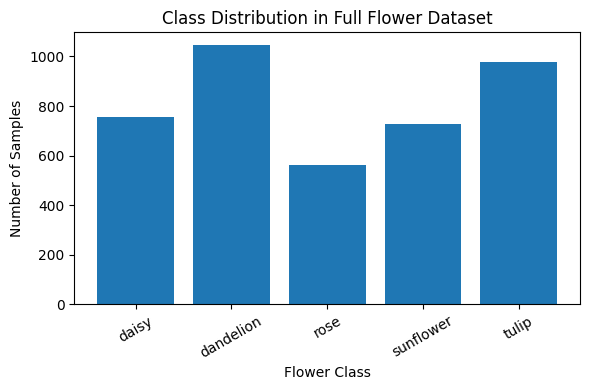

In [7]:

# Count samples per class in full dataset
unique, counts = np.unique(y, return_counts=True)
total_counts = counts

plt.figure(figsize=(6,4))
plt.bar(class_names, total_counts)
plt.xlabel("Flower Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Full Flower Dataset")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()





In [67]:
import pandas as pd

label_map = pd.read_csv("flower_label_mapping.csv")
print(label_map)

# Or as a dictionary:
id_to_name = dict(zip(label_map["label_id"], label_map["class_name"]))
print("\nID → Class name mapping:")
for k, v in id_to_name.items():
    print(f"{k} -> {v}")


   label_id class_name
0         0      daisy
1         1  dandelion
2         2       rose
3         3  sunflower
4         4      tulip

ID → Class name mapping:
0 -> daisy
1 -> dandelion
2 -> rose
3 -> sunflower
4 -> tulip


# **Split the train and test**

In [8]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test (you can change test_size if needed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (3252, 512) (3252,)
Test shape: (813, 512) (813,)


Total per class:  [ 757 1045  560  726  977]
Train per class:  [605 836 448 581 782]
Test per class:   [152 209 112 145 195]


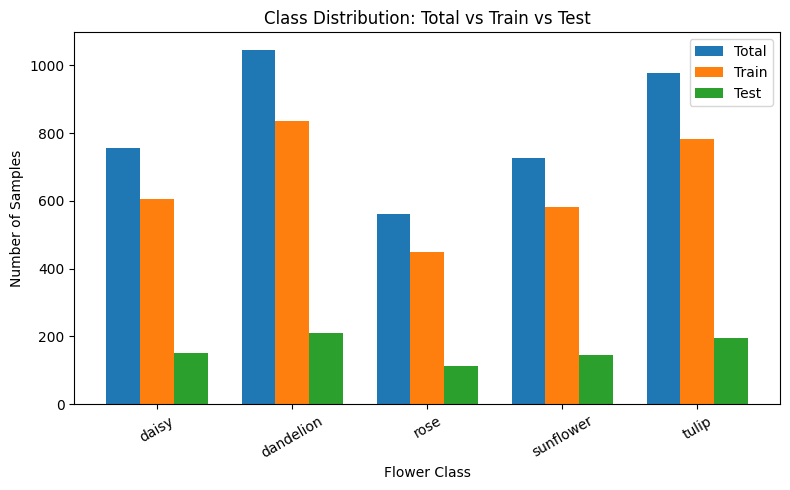

In [9]:

_, train_counts = np.unique(y_train, return_counts=True)
_, test_counts  = np.unique(y_test,  return_counts=True)


print("Total per class: ", total_counts)
print("Train per class: ", train_counts)
print("Test per class:  ", test_counts)


indices = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(indices - width, total_counts, width=width, label="Total")
plt.bar(indices,         train_counts, width=width, label="Train")
plt.bar(indices + width, test_counts,  width=width, label="Test")

plt.xticks(indices, class_names, rotation=30)
plt.xlabel("Flower Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution: Total vs Train vs Test")
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
_, idx_test = train_test_split(
    np.arange(len(X)),
    test_size=0.2,
    random_state=42,
    stratify=y
)


# CLASSIFIED, MISCLASSIFIED & CONFUSED **SAMPLES**

<Figure size 600x600 with 0 Axes>

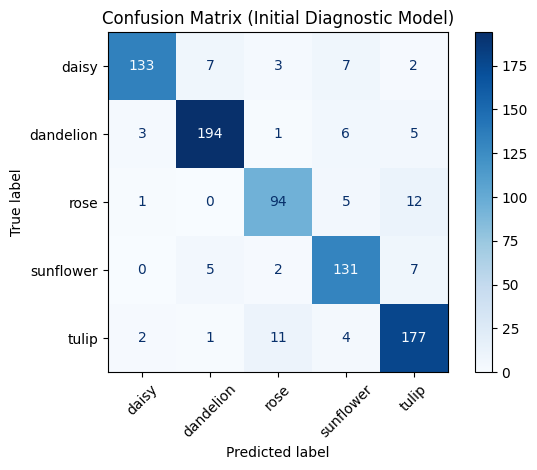

Total Test Samples: 813
Correctly Classified: 729
Misclassified: 84

 CORRECTLY CLASSIFIED SAMPLES (first 10):
tulip/402525114_eaa60c8341_m.jpg | True: tulip | Pred: tulip
sunflower/6116210027_61923f4b64.jpg | True: sunflower | Pred: sunflower
dandelion/7368449232_c99f49b2e6_n.jpg | True: dandelion | Pred: dandelion
dandelion/4721773235_429acdf496_n.jpg | True: dandelion | Pred: dandelion
sunflower/4877195645_791c3a83b9_m.jpg | True: sunflower | Pred: sunflower
daisy/4666648087_b10f376f19.jpg | True: daisy | Pred: daisy
dandelion/5673112305_02fe19297b_n.jpg | True: dandelion | Pred: dandelion
dandelion/14053173516_a00150a919_m.jpg | True: dandelion | Pred: dandelion
dandelion/14278605962_d3cce5522f.jpg | True: dandelion | Pred: dandelion
tulip/3498663243_42b39b4185_m.jpg | True: tulip | Pred: tulip

 MISCLASSIFIED SAMPLES (first 10):
sunflower/5339004958_a0a6f385fd_m.jpg | True: sunflower | Pred: tulip
daisy/17821980772_35164ae1e8_n.jpg | True: daisy | Pred: sunflower
daisy/8681746439_

In [11]:


from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


diagnostic_model = SVC(kernel="rbf", probability=True, random_state=42)
diagnostic_model.fit(X_train, y_train)

y_pred = diagnostic_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (Initial Diagnostic Model)")
plt.tight_layout()
plt.show()


# 3. CORRECT & MISCLASSIFIED SAMPLES

correct_idx = np.where(y_test == y_pred)[0]
mis_idx     = np.where(y_test != y_pred)[0]

print(f"Total Test Samples: {len(y_test)}")
print(f"Correctly Classified: {len(correct_idx)}")
print(f"Misclassified: {len(mis_idx)}")

# Map back to filenames
test_filenames = filenames.iloc[idx_test, 0].values

print("\n CORRECTLY CLASSIFIED SAMPLES (first 10):")
for i in correct_idx[:10]:
    print(f"{test_filenames[i]} | True: {class_names[y_test[i]]} | Pred: {class_names[y_pred[i]]}")

print("\n MISCLASSIFIED SAMPLES (first 10):")
for i in mis_idx[:10]:
    print(f"{test_filenames[i]} | True: {class_names[y_test[i]]} | Pred: {class_names[y_pred[i]]}")


# 4. MOST CONFUSED CLASS PAIR

cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)

true_cls, pred_cls = np.unravel_index(np.argmax(cm_off_diag), cm_off_diag.shape)

print("\n MOST CONFUSED CLASS PAIR:")
print(f"True Class: {class_names[true_cls]}")
print(f"Predicted As: {class_names[pred_cls]}")
print(f"Number of Confusions: {cm_off_diag[true_cls, pred_cls]}")

print("\n CONFUSED SAMPLE EXAMPLES (first 10):")
count = 0
for i in mis_idx:
    if y_test[i] == true_cls and y_pred[i] == pred_cls:
        print(f"{test_filenames[i]} | True: {class_names[y_test[i]]} | Pred: {class_names[y_pred[i]]}")
        count += 1
        if count >= 10:
            break

if count == 0:
    print("No confused samples found for this pair in test subset.")


In [26]:
# Get misclassified sample indices
mis_idx = np.where(y_test != y_pred)[0]

print("Total Misclassified Samples:", len(mis_idx))
print("\nShowing first 15 misclassified samples:\n")

for i in mis_idx[:15]:
    print(f"Image: {test_filenames[i]}")
    print(f" True Label: {class_names[y_test[i]]}")
    print(f" Predicted: {class_names[y_pred[i]]}")
    print("-" * 40)


Total Misclassified Samples: 123

Showing first 15 misclassified samples:

Image: daisy/17821980772_35164ae1e8_n.jpg
 True Label: daisy
 Predicted: sunflower
----------------------------------------
Image: daisy/8681746439_d6beeefbf9.jpg
 True Label: daisy
 Predicted: dandelion
----------------------------------------
Image: tulip/15147473067_7c5498eb0e_m.jpg
 True Label: tulip
 Predicted: rose
----------------------------------------
Image: dandelion/5109496141_8dcf673d43_n.jpg
 True Label: dandelion
 Predicted: sunflower
----------------------------------------
Image: rose/388405293_4db1d71f21_n.jpg
 True Label: rose
 Predicted: dandelion
----------------------------------------
Image: dandelion/15005530987_e13b328047_n.jpg
 True Label: dandelion
 Predicted: daisy
----------------------------------------
Image: dandelion/34647026976_68af8875e0_n.jpg
 True Label: dandelion
 Predicted: tulip
----------------------------------------
Image: tulip/16930105456_8b826dc4a8_n.jpg
 True Label:

# **Normalization, PCA, Feature Selection,K-fold**

In [13]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd

cv4 = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

results = []

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

pca_components = [2, 10]

feature_selectors = {
    "VarianceThreshold": VarianceThreshold(threshold=0.01),
    "ANOVA": SelectKBest(score_func=f_classif, k=64)
}

for scaler_name, scaler in scalers.items():
    for n_comp in pca_components:
        for fs_name, fs in feature_selectors.items():

            pipeline = Pipeline([
                ('scaler', scaler),
                ('pca', PCA(n_components=n_comp)),
                ('fs', fs),
                ('model', KNeighborsClassifier(n_neighbors=5))
            ])

            # ======== CROSS VALIDATION METRICS ========
            cv_scores = cross_validate(
                pipeline,
                X_train,
                y_train,
                cv=cv4,
                scoring=['accuracy', 'f1_macro', 'roc_auc_ovr_weighted'],
                return_train_score=False
            )


            pipeline.fit(X_train, y_train)


            y_test_pred = pipeline.predict(X_test)
            y_test_prob = pipeline.predict_proba(X_test)

            # Test metrics
            test_accuracy = accuracy_score(y_test, y_test_pred)
            test_f1 = f1_score(y_test, y_test_pred, average='macro')

            # ROC-AUC (multiclass safe)
            from sklearn.preprocessing import label_binarize
            y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
            test_roc_auc = roc_auc_score(y_test_bin, y_test_prob, multi_class='ovr')

            results.append({
                "Scaler": scaler_name,
                "PCA": n_comp,
                "Feature_Selection": fs_name,

                # Cross Validation Metrics
                "CV_Mean_Accuracy": np.mean(cv_scores['test_accuracy']),
                "CV_Mean_F1": np.mean(cv_scores['test_f1_macro']),
                "CV_Mean_ROC_AUC": np.mean(cv_scores['test_roc_auc_ovr_weighted']),

                # TEST METRICS
                "Test_Accuracy": test_accuracy,
                "Test_F1": test_f1,
                "Test_ROC_AUC": test_roc_auc
            })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by strong scientific priority
results_df_sorted = results_df.sort_values(
    by=["CV_Mean_ROC_AUC", "CV_Mean_F1", "CV_Mean_Accuracy"],
    ascending=False
).reset_index(drop=True)

print("Preprocessing Comparison Table with CV + Test Metrics:")
display(results_df_sorted)







Preprocessing Comparison Table with CV + Test Metrics:


,Scaler,PCA,Feature_Selection,CV_Mean_Accuracy,CV_Mean_F1,CV_Mean_ROC_AUC,Test_Accuracy,Test_F1,Test_ROC_AUC
0,MinMaxScaler,10,VarianceThreshold,0.824108,0.816190,0.955253,0.845018,0.837643,0.955909
1,MinMaxScaler,10,ANOVA,0.824108,0.816330,0.955241,0.846248,0.838976,0.956200
2,StandardScaler,10,VarianceThreshold,0.821648,0.815532,0.953275,0.829028,0.820267,0.956330
3,StandardScaler,10,ANOVA,0.823801,0.818317,0.952649,0.832718,0.823575,0.956576
4,StandardScaler,2,VarianceThreshold,0.516913,0.484987,0.817297,0.528905,0.497990,0.814463
5,StandardScaler,2,ANOVA,0.516913,0.484987,0.817297,0.528905,0.497990,0.814463
6,MinMaxScaler,2,VarianceThreshold,0.525215,0.495870,0.808237,0.526445,0.500344,0.807380
7,MinMaxScaler,2,ANOVA,0.525215,0.495870,0.808237,0.526445,0.500344,0.807380


In [14]:
# Take the best row (highest Mean_Accuracy)
best_row = results_df_sorted.iloc[0]
print("Best Preprocessing Configuration:")
display(best_row)


Best Preprocessing Configuration:


,0
Scaler,MinMaxScaler
PCA,10
Feature_Selection,VarianceThreshold
CV_Mean_Accuracy,0.824108
CV_Mean_F1,0.81619
CV_Mean_ROC_AUC,0.955253
Test_Accuracy,0.845018
Test_F1,0.837643
Test_ROC_AUC,0.955909


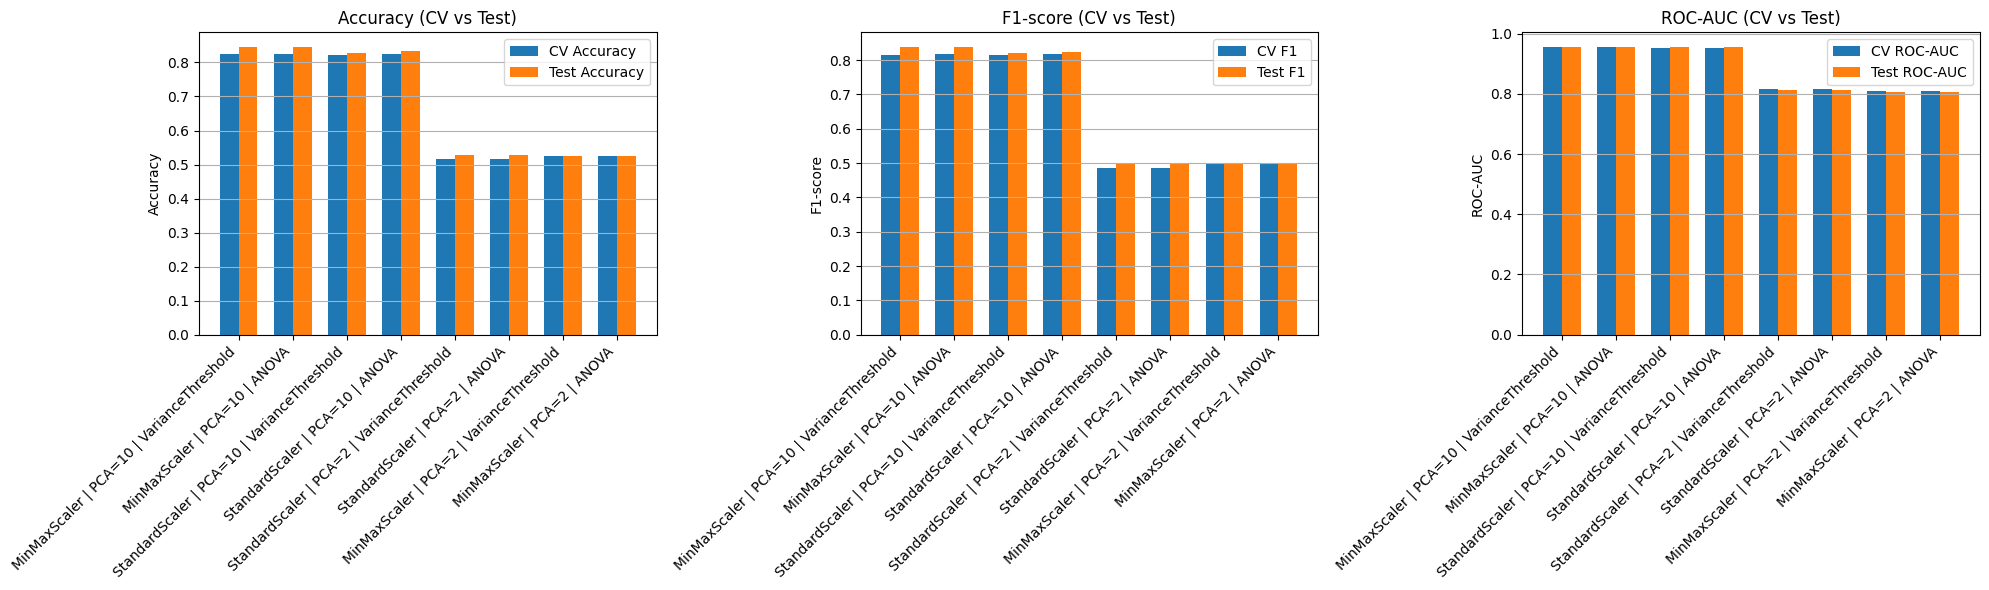

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Make a copy and create a label for each config
plot_df = results_df_sorted.copy()

plot_df["Config"] = (
    plot_df["Scaler"]
    + " | PCA=" + plot_df["PCA"].astype(str)
    + " | " + plot_df["Feature_Selection"]
)

indices = np.arange(len(plot_df))
width = 0.35  # bar width

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)

#  Accuracy subplot
axes[0].bar(indices - width/2, plot_df["CV_Mean_Accuracy"], width, label="CV Accuracy")
axes[0].bar(indices + width/2, plot_df["Test_Accuracy"], width, label="Test Accuracy")
axes[0].set_title("Accuracy (CV vs Test)")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(indices)
axes[0].set_xticklabels(plot_df["Config"], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y')

#  F1-score subplot
axes[1].bar(indices - width/2, plot_df["CV_Mean_F1"], width, label="CV F1")
axes[1].bar(indices + width/2, plot_df["Test_F1"], width, label="Test F1")
axes[1].set_title("F1-score (CV vs Test)")
axes[1].set_ylabel("F1-score")
axes[1].set_xticks(indices)
axes[1].set_xticklabels(plot_df["Config"], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y')

# ROC-AUC subplot
axes[2].bar(indices - width/2, plot_df["CV_Mean_ROC_AUC"], width, label="CV ROC-AUC")
axes[2].bar(indices + width/2, plot_df["Test_ROC_AUC"], width, label="Test ROC-AUC")
axes[2].set_title("ROC-AUC (CV vs Test)")
axes[2].set_ylabel("ROC-AUC")
axes[2].set_xticks(indices)
axes[2].set_xticklabels(plot_df["Config"], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()


# **PCA Visualization of Correct vs Misclassified Samples**

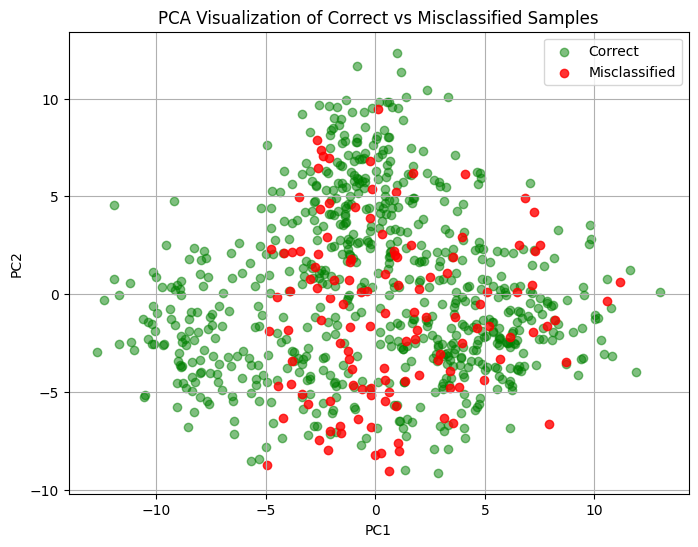

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce test features to 2D for visualization
pca_vis = PCA(n_components=2)
X_test_2D = pca_vis.fit_transform(X_test)

correct_idx = np.where(y_test == y_pred)[0]
mis_idx = np.where(y_test != y_pred)[0]

plt.figure(figsize=(8,6))
plt.scatter(X_test_2D[correct_idx, 0], X_test_2D[correct_idx, 1],
            c='green', label='Correct', alpha=0.5)

plt.scatter(X_test_2D[mis_idx, 0], X_test_2D[mis_idx, 1],
            c='red', label='Misclassified', alpha=0.8)

plt.title("PCA Visualization of Correct vs Misclassified Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()


# **Classifiers**

# **KNN**

KNN Accuracy Table for Different k and Distance Metrics:


,k,Euclidean_Train_Acc,Euclidean_Test_Acc,Manhattan_Train_Acc,Manhattan_Test_Acc,Minkowski_Train_Acc,Minkowski_Test_Acc
0,1,0.998770,0.854859,0.998770,0.852399,0.998770,0.854859
1,3,0.935424,0.861009,0.937269,0.856089,0.935424,0.861009
2,5,0.919434,0.874539,0.921894,0.872079,0.919434,0.874539
3,7,0.915744,0.879459,0.916667,0.859779,0.915744,0.879459
4,9,0.909287,0.878229,0.905597,0.862239,0.909287,0.878229
5,11,0.905289,0.881919,0.904674,0.864699,0.905289,0.881919
6,13,0.902214,0.876999,0.899446,0.867159,0.902214,0.876999
7,16,0.900369,0.875769,0.893604,0.867159,0.900369,0.875769


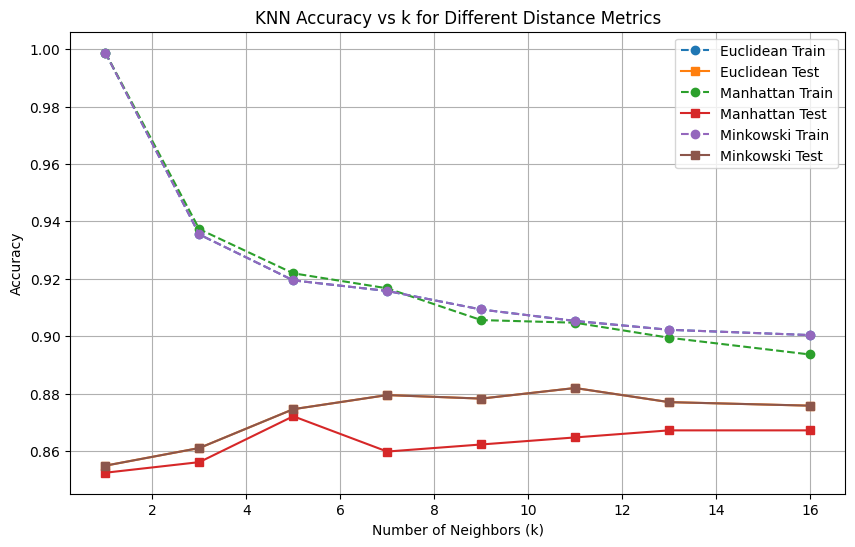

In [16]:




from collections import defaultdict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

distance_metrics = ['euclidean', 'manhattan', 'minkowski']
k_values = [1, 3, 5, 7, 9, 11, 13, 16]

knn_results = defaultdict(list)


for metric in distance_metrics:
    train_accs = []
    test_accs = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)

        #  TRAIN
        knn.fit(X_train, y_train)

        #  PREDICT
        y_train_pred = knn.predict(X_train)
        y_test_pred = knn.predict(X_test)

        #  ACCURACY
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        train_accs.append(train_acc)
        test_accs.append(test_acc)

    knn_results[f"{metric}_train"] = train_accs
    knn_results[f"{metric}_test"] = test_accs



table_data = {
    "k": k_values,
    "Euclidean_Train_Acc": knn_results["euclidean_train"],
    "Euclidean_Test_Acc": knn_results["euclidean_test"],
    "Manhattan_Train_Acc": knn_results["manhattan_train"],
    "Manhattan_Test_Acc": knn_results["manhattan_test"],
    "Minkowski_Train_Acc": knn_results["minkowski_train"],
    "Minkowski_Test_Acc": knn_results["minkowski_test"]
}

knn_results_df = pd.DataFrame(table_data)

print("KNN Accuracy Table for Different k and Distance Metrics:")
display(knn_results_df)



plt.figure(figsize=(10,6))

for metric in distance_metrics:
    plt.plot(k_values, knn_results[f"{metric}_train"], '--o', label=f"{metric.capitalize()} Train")
    plt.plot(k_values, knn_results[f"{metric}_test"], '-s', label=f"{metric.capitalize()} Test")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k for Different Distance Metrics")
plt.legend()
plt.grid(True)
plt.show()


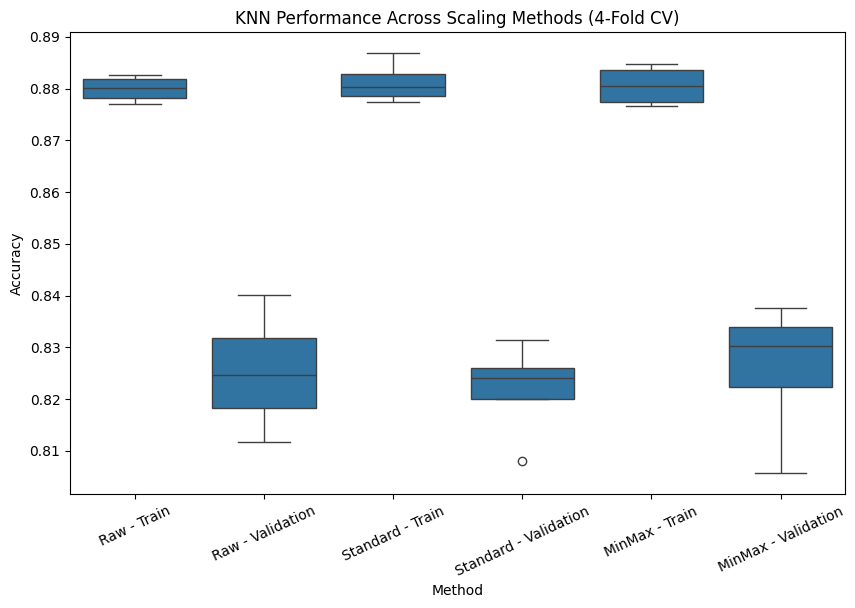

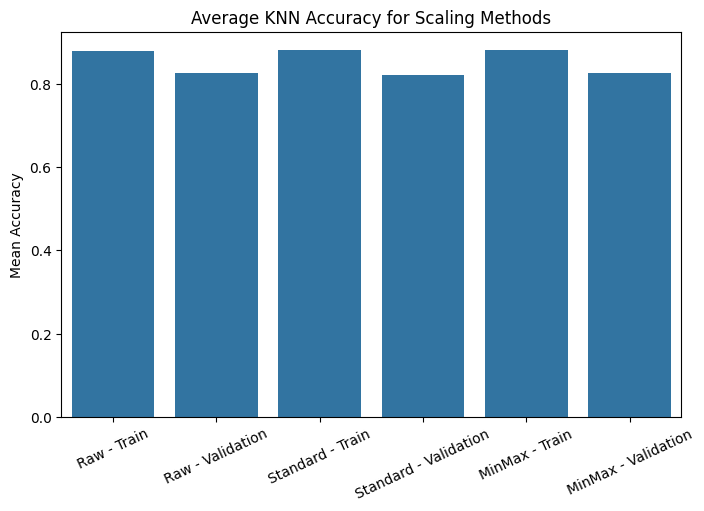

 Mean Validation Accuracy:
Raw: 0.8253382533825337
StandardScaler: 0.8219557195571956
MinMaxScaler: 0.8259532595325954


In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

k = 5  # chosen k

pca = PCA(n_components=10)
fs = VarianceThreshold(threshold=0.01)

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

X_train_std = standard_scaler.fit_transform(X_train)
X_train_mm = minmax_scaler.fit_transform(X_train)

# Apply PCA + FS
X_std_final = fs.fit_transform(pca.fit_transform(X_train_std))
X_mm_final = fs.fit_transform(pca.fit_transform(X_train_mm))
X_raw_final = fs.fit_transform(pca.fit_transform(X_train))  # RAW

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

train_scores_raw, val_scores_raw = [], []
train_scores_std, val_scores_std = [], []
train_scores_mm, val_scores_mm = [], []

for train_idx, val_idx in cv.split(X_train, y_train):

    # RAW
    knn_raw = KNeighborsClassifier(n_neighbors=k, metric="minkowski")
    knn_raw.fit(X_raw_final[train_idx], y_train[train_idx])
    train_scores_raw.append(knn_raw.score(X_raw_final[train_idx], y_train[train_idx]))
    val_scores_raw.append(knn_raw.score(X_raw_final[val_idx], y_train[val_idx]))

    # StandardScaler
    knn_std = KNeighborsClassifier(n_neighbors=k, metric="minkowski")
    knn_std.fit(X_std_final[train_idx], y_train[train_idx])
    train_scores_std.append(knn_std.score(X_std_final[train_idx], y_train[train_idx]))
    val_scores_std.append(knn_std.score(X_std_final[val_idx], y_train[val_idx]))

    # MinMaxScaler
    knn_mm = KNeighborsClassifier(n_neighbors=k, metric="minkowski")
    knn_mm.fit(X_mm_final[train_idx], y_train[train_idx])
    train_scores_mm.append(knn_mm.score(X_mm_final[train_idx], y_train[train_idx]))
    val_scores_mm.append(knn_mm.score(X_mm_final[val_idx], y_train[val_idx]))


data = {
    "Raw - Train": train_scores_raw,
    "Raw - Validation": val_scores_raw,
    "Standard - Train": train_scores_std,
    "Standard - Validation": val_scores_std,
    "MinMax - Train": train_scores_mm,
    "MinMax - Validation": val_scores_mm
}

# Convert to dataframe
train_val_data = []
for key, values in data.items():
    for value in values:
        train_val_data.append([key, value])

train_val_data = pd.DataFrame(train_val_data, columns=["Method", "Accuracy"])



plt.figure(figsize=(10,6))
sns.boxplot(x="Method", y="Accuracy", data=train_val_data)
plt.xticks(rotation=25)
plt.title("KNN Performance Across Scaling Methods (4-Fold CV)")
plt.ylabel("Accuracy")
plt.show()



means = {key: np.mean(values) for key, values in data.items()}

plt.figure(figsize=(8,5))
sns.barplot(x=list(means.keys()), y=list(means.values()))
plt.xticks(rotation=25)
plt.ylabel("Mean Accuracy")
plt.title("Average KNN Accuracy for Scaling Methods")
plt.show()



print(" Mean Validation Accuracy:")
print("Raw:", np.mean(val_scores_raw))
print("StandardScaler:", np.mean(val_scores_std))
print("MinMaxScaler:", np.mean(val_scores_mm))


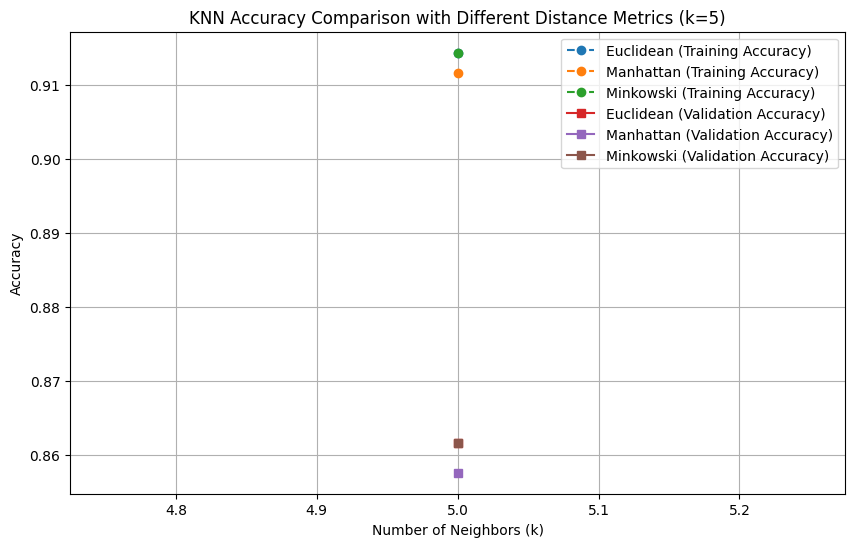

Best k = 5, Distance Metric = Euclidean:
  Training Accuracy   : 0.9144
  Validation Accuracy : 0.8616
----
Best k = 5, Distance Metric = Manhattan:
  Training Accuracy   : 0.9116
  Validation Accuracy : 0.8576
----
Best k = 5, Distance Metric = Minkowski:
  Training Accuracy   : 0.9144
  Validation Accuracy : 0.8616
----


In [18]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np


best_scaler = StandardScaler()
best_k = 5
distance_metrics = ['euclidean', 'manhattan', 'minkowski']

# Scale data
X_train_scaled = best_scaler.fit_transform(X_train)

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

train_accuracies = {}
val_accuracies = {}


for metric in distance_metrics:
    train_scores = []
    val_scores = []

    for train_index, val_index in cv.split(X_train_scaled, y_train):
        X_train_fold = X_train_scaled[train_index]
        X_val_fold   = X_train_scaled[val_index]

        y_train_fold = y_train[train_index]
        y_val_fold   = y_train[val_index]

        knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
        knn.fit(X_train_fold, y_train_fold)

        train_scores.append(knn.score(X_train_fold, y_train_fold))
        val_scores.append(knn.score(X_val_fold, y_val_fold))

    train_accuracies[metric] = np.mean(train_scores)
    val_accuracies[metric] = np.mean(val_scores)


plt.figure(figsize=(10, 6))

for metric in distance_metrics:
    plt.plot([best_k], [train_accuracies[metric]],
             marker='o', linestyle='--',
             label=f'{metric.capitalize()} (Training Accuracy)')

for metric in distance_metrics:
    plt.plot([best_k], [val_accuracies[metric]],
             marker='s',
             label=f'{metric.capitalize()} (Validation Accuracy)')

plt.title(f"KNN Accuracy Comparison with Different Distance Metrics (k={best_k})")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



for metric in distance_metrics:
    print(f"Best k = {best_k}, Distance Metric = {metric.capitalize()}:")
    print(f"  Training Accuracy   : {train_accuracies[metric]:.4f}")
    print(f"  Validation Accuracy : {val_accuracies[metric]:.4f}")
    print("----")


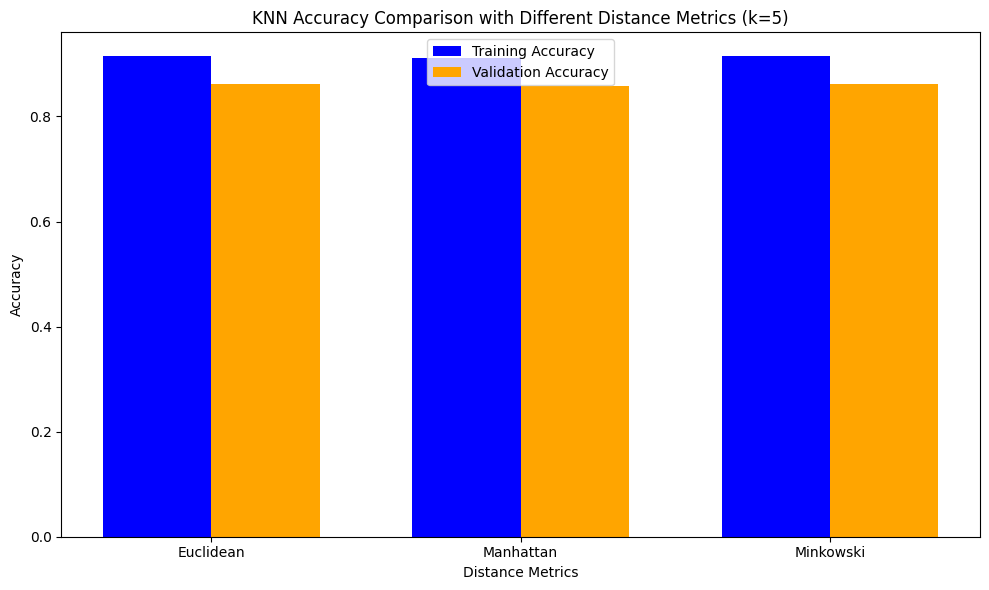

In [19]:


train_accuracies_mean = [
    train_accuracies['euclidean'],
    train_accuracies['manhattan'],
    train_accuracies['minkowski']
]

val_accuracies_mean = [
    val_accuracies['euclidean'],
    val_accuracies['manhattan'],
    val_accuracies['minkowski']
]

labels = ['Euclidean', 'Manhattan', 'Minkowski']
bar_width = 0.35
index = np.arange(len(labels))

plt.figure(figsize=(10, 6))
plt.bar(index, train_accuracies_mean, bar_width, label='Training Accuracy', color='blue')
plt.bar(index + bar_width, val_accuracies_mean, bar_width, label='Validation Accuracy', color='orange')

plt.xlabel('Distance Metrics')
plt.ylabel('Accuracy')
plt.title(f'KNN Accuracy Comparison with Different Distance Metrics (k={best_k})')
plt.xticks(index + bar_width / 2, labels)
plt.legend()
plt.tight_layout()
plt.show()


 CROSS VALIDATION RESULTS (4-FOLD)
CV Accuracy : 0.8431734317343174
CV F1 Score : 0.8372452813094371
CV ROC-AUC  : 0.9734286774711308

 TEST SET RESULTS
Test Accuracy : 0.8487084870848709
Test F1 Score : 0.8420171530575171
Test ROC-AUC  : 0.975881024678827


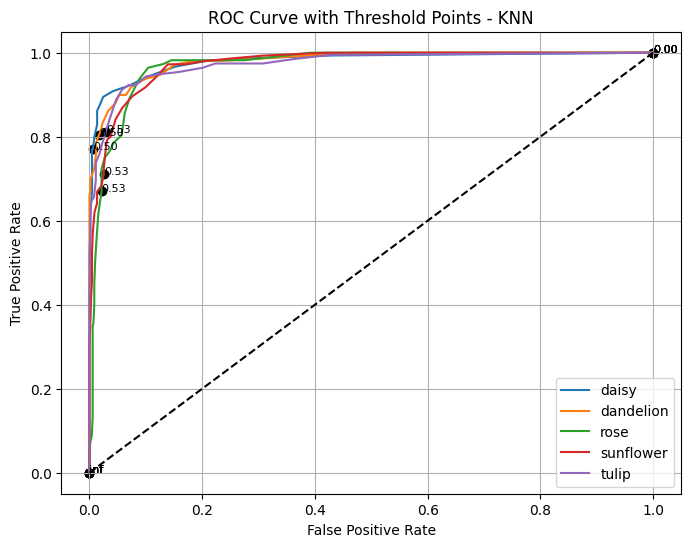

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import matplotlib.pyplot as plt
import numpy as np

best_k = 30

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('fs', VarianceThreshold(threshold=0.01)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, metric='minkowski'))
])

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'roc_auc': 'roc_auc_ovr'
}

cv_scores = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print(" CROSS VALIDATION RESULTS (4-FOLD)")
print("CV Accuracy :", np.mean(cv_scores['test_accuracy']))
print("CV F1 Score :", np.mean(cv_scores['test_f1']))
print("CV ROC-AUC  :", np.mean(cv_scores['test_roc_auc']))



pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

print("\n TEST SET RESULTS")
print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("Test F1 Score :", f1_score(y_test, y_pred, average='macro'))
print("Test ROC-AUC  :", roc_auc_score(y_test, y_prob, multi_class='ovr'))



classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob[:, i])

    plt.plot(fpr, tpr, label=f"{class_names[i]}")


    for j in np.linspace(0, len(thresholds)-1, 3, dtype=int):
        plt.scatter(fpr[j], tpr[j], color='black')
        plt.text(fpr[j], tpr[j],
                 f"{thresholds[j]:.2f}",
                 fontsize=8)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Threshold Points - KNN")
plt.legend()
plt.grid(True)
plt.show()


# **Random forest**

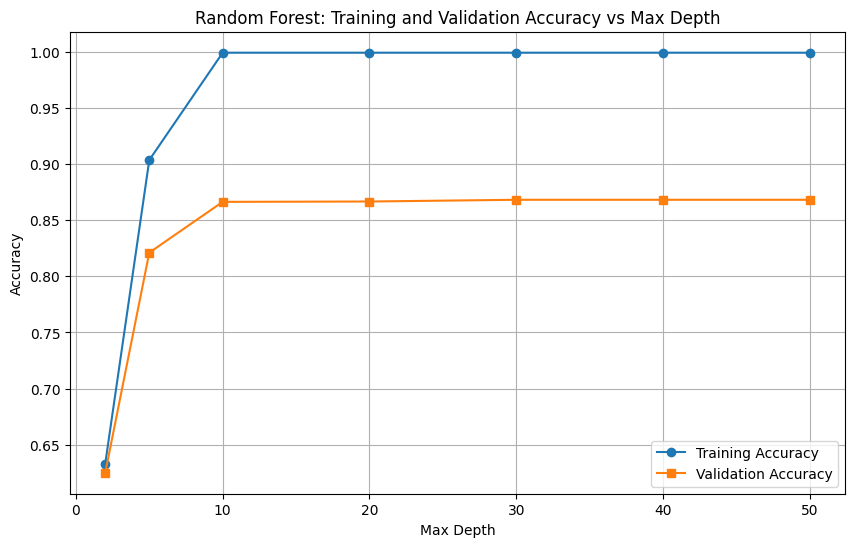

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

max_depth_values = [2,5,10,20,30,40,50]
train_acc = []
val_acc = []

for depth in max_depth_values:
    rf = RandomForestClassifier(n_estimators=200, max_depth=depth, random_state=42)
    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        rf.fit(X_tr, y_tr)
        train_scores.append(rf.score(X_tr, y_tr))
        val_scores.append(rf.score(X_val, y_val))

    train_acc.append(np.mean(train_scores))
    val_acc.append(np.mean(val_scores))

plt.figure(figsize=(10,6))
plt.plot(max_depth_values, train_acc, marker='o', label="Training Accuracy")
plt.plot(max_depth_values, val_acc, marker='s', label="Validation Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Random Forest: Training and Validation Accuracy vs Max Depth")
plt.legend()
plt.grid(True)
plt.show()


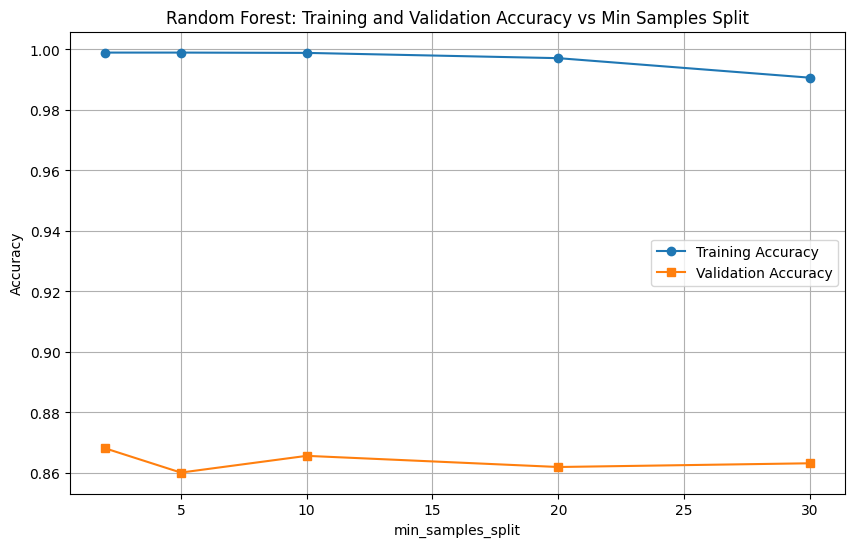

In [22]:
min_samples_split_values = [2,5,10,20,30]
train_acc = []
val_acc = []

for mss in min_samples_split_values:
    rf = RandomForestClassifier(n_estimators=200, min_samples_split=mss, random_state=42)
    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        rf.fit(X_tr, y_tr)
        train_scores.append(rf.score(X_tr, y_tr))
        val_scores.append(rf.score(X_val, y_val))

    train_acc.append(np.mean(train_scores))
    val_acc.append(np.mean(val_scores))

plt.figure(figsize=(10,6))
plt.plot(min_samples_split_values, train_acc, marker='o', label="Training Accuracy")
plt.plot(min_samples_split_values, val_acc, marker='s', label="Validation Accuracy")
plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")
plt.title("Random Forest: Training and Validation Accuracy vs Min Samples Split")
plt.legend()
plt.grid(True)
plt.show()


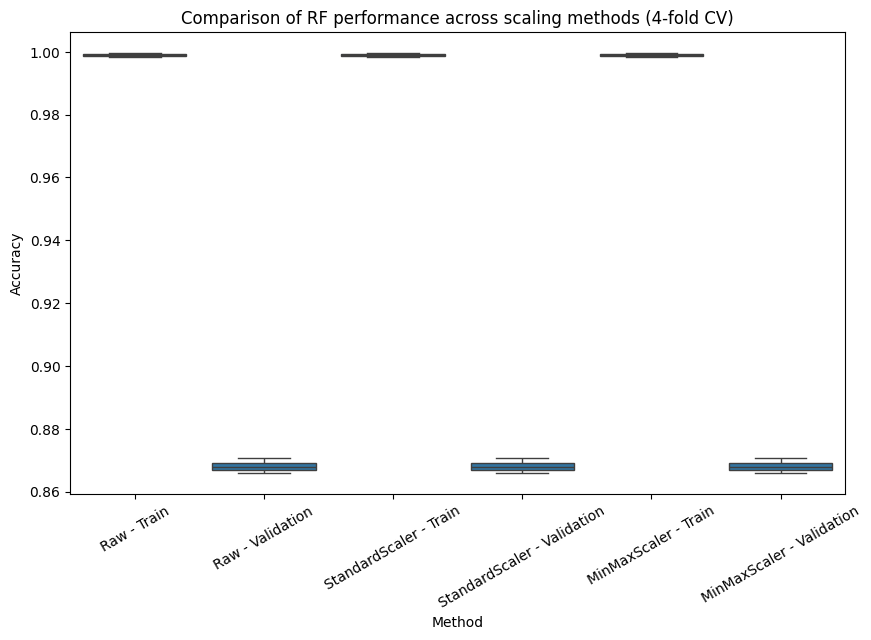

In [23]:
scalers = {
    "Raw": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

rf_results = {}

for name, scaler in scalers.items():
    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        if scaler:
            X_tr = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)

        rf = RandomForestClassifier(n_estimators=200, random_state=42)
        rf.fit(X_tr, y_tr)

        train_scores.append(rf.score(X_tr, y_tr))
        val_scores.append(rf.score(X_val, y_val))

    rf_results[name] = {
        "Train": train_scores,
        "Validation": val_scores
    }

# Boxplot visualization
plot_data = []
for key, scores in rf_results.items():
    for val in scores["Train"]:
        plot_data.append([f"{key} - Train", val])
    for val in scores["Validation"]:
        plot_data.append([f"{key} - Validation", val])

df_plot = pd.DataFrame(plot_data, columns=["Method", "Accuracy"])

plt.figure(figsize=(10,6))
sns.boxplot(x="Method", y="Accuracy", data=df_plot)
plt.xticks(rotation=30)
plt.title("Comparison of RF performance across scaling methods (4-fold CV)")
plt.show()


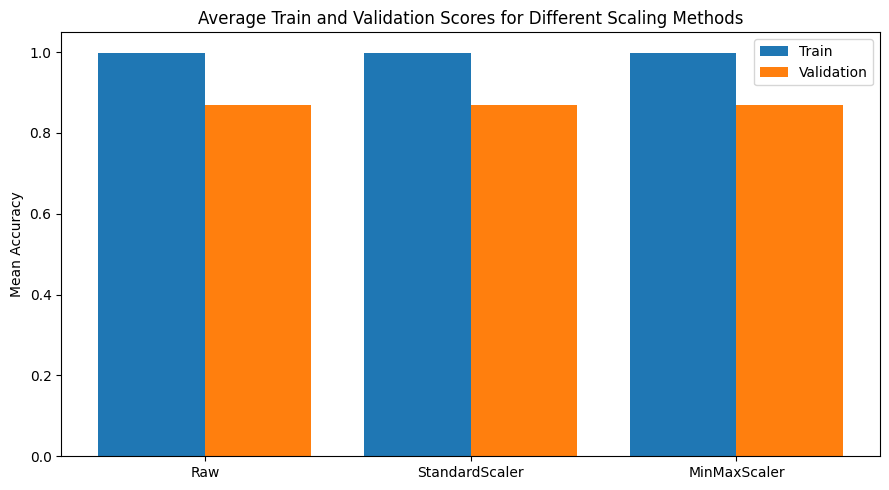

In [24]:
means_train = [np.mean(rf_results[k]["Train"]) for k in rf_results]
means_val = [np.mean(rf_results[k]["Validation"]) for k in rf_results]

labels = list(rf_results.keys())
x = np.arange(len(labels))

plt.figure(figsize=(9,5))
plt.bar(x - 0.2, means_train, 0.4, label="Train")
plt.bar(x + 0.2, means_val, 0.4, label="Validation")
plt.xticks(x, labels)
plt.ylabel("Mean Accuracy")
plt.title("Average Train and Validation Scores for Different Scaling Methods")
plt.legend()
plt.tight_layout()
plt.show()


 RANDOM FOREST – 4-FOLD CV RESULTS
CV Accuracy : 0.8287207872078721
CV F1 Score : 0.8207322019781637
CV ROC-AUC  : 0.9724317077177798

 RANDOM FOREST – TEST SET RESULTS
Test Accuracy : 0.8364083640836408
Test F1 Score : 0.8286459121598243
Test ROC-AUC  : 0.9725597080762857


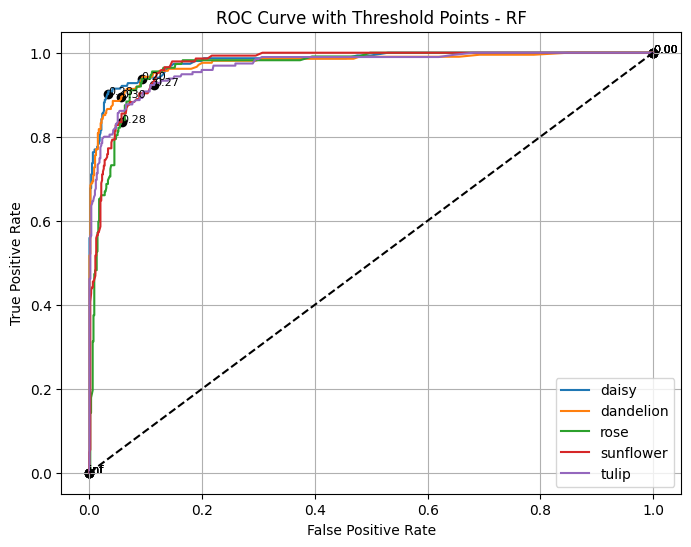

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import matplotlib.pyplot as plt
import numpy as np

# ================= RF MODEL =================
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('fs', VarianceThreshold(threshold=0.01)),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'roc_auc': 'roc_auc_ovr'
}

# ========== CROSS VALIDATION ==========
cv_scores = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print(" RANDOM FOREST – 4-FOLD CV RESULTS")
print("CV Accuracy :", np.mean(cv_scores['test_accuracy']))
print("CV F1 Score :", np.mean(cv_scores['test_f1']))
print("CV ROC-AUC  :", np.mean(cv_scores['test_roc_auc']))


# ========== TRAIN ON FULL TRAIN SET ==========
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)

print("\n RANDOM FOREST – TEST SET RESULTS")
print("Test Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Test F1 Score :", f1_score(y_test, y_pred_rf, average='macro'))
print("Test ROC-AUC  :", roc_auc_score(y_test, y_prob_rf, multi_class='ovr'))


# ========== ROC CURVE PLOT ==========
# classes = np.unique(y_train)
# y_test_bin = label_binarize(y_test, classes=classes)

# plt.figure(figsize=(7,6))

# for i in range(len(classes)):
#     fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
#     plt.plot(fpr, tpr, label=f'Class {classes[i]}')

# plt.plot([0,1], [0,1], 'k--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve - Random Forest")
# plt.legend()
# plt.grid()
# plt.show()



classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])

    plt.plot(fpr, tpr, label=f"{class_names[i]}")

    # Mark 3 threshold points for each class
    for j in np.linspace(0, len(thresholds)-1, 3, dtype=int):
        plt.scatter(fpr[j], tpr[j], color='black')
        plt.text(fpr[j], tpr[j],
                 f"{thresholds[j]:.2f}",
                 fontsize=8)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Threshold Points - RF")
plt.legend()
plt.grid(True)
plt.show()



# **SVM**

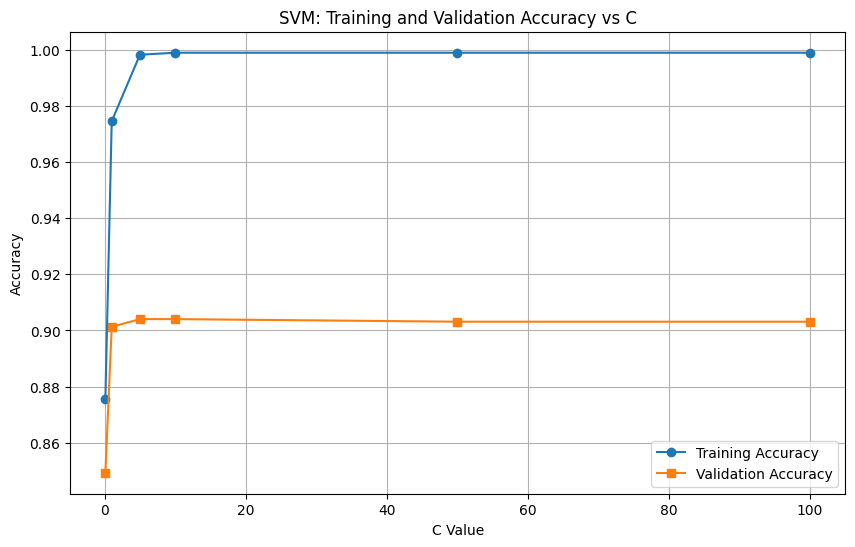

In [29]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

C_values = [0.1, 1, 5, 10, 50, 100]
train_acc = []
val_acc = []

for C in C_values:
    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        svm = SVC(C=C, kernel='rbf')
        svm.fit(X_tr, y_tr)

        train_scores.append(svm.score(X_tr, y_tr))
        val_scores.append(svm.score(X_val, y_val))

    train_acc.append(np.mean(train_scores))
    val_acc.append(np.mean(val_scores))

plt.figure(figsize=(10,6))
plt.plot(C_values, train_acc, marker='o', label="Training Accuracy")
plt.plot(C_values, val_acc, marker='s', label="Validation Accuracy")
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("SVM: Training and Validation Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()


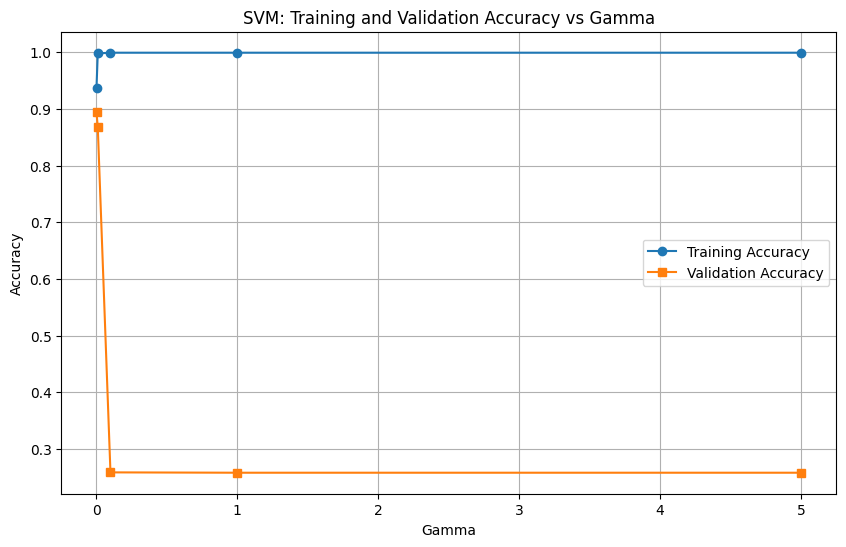

In [30]:
gamma_values = [0.001, 0.01, 0.1, 1, 5]
train_acc = []
val_acc = []

for gamma in gamma_values:
    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        svm = SVC(gamma=gamma, kernel='rbf')
        svm.fit(X_tr, y_tr)

        train_scores.append(svm.score(X_tr, y_tr))
        val_scores.append(svm.score(X_val, y_val))

    train_acc.append(np.mean(train_scores))
    val_acc.append(np.mean(val_scores))

plt.figure(figsize=(10,6))
plt.plot(gamma_values, train_acc, marker='o', label="Training Accuracy")
plt.plot(gamma_values, val_acc, marker='s', label="Validation Accuracy")
plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.title("SVM: Training and Validation Accuracy vs Gamma")
plt.legend()
plt.grid(True)
plt.show()


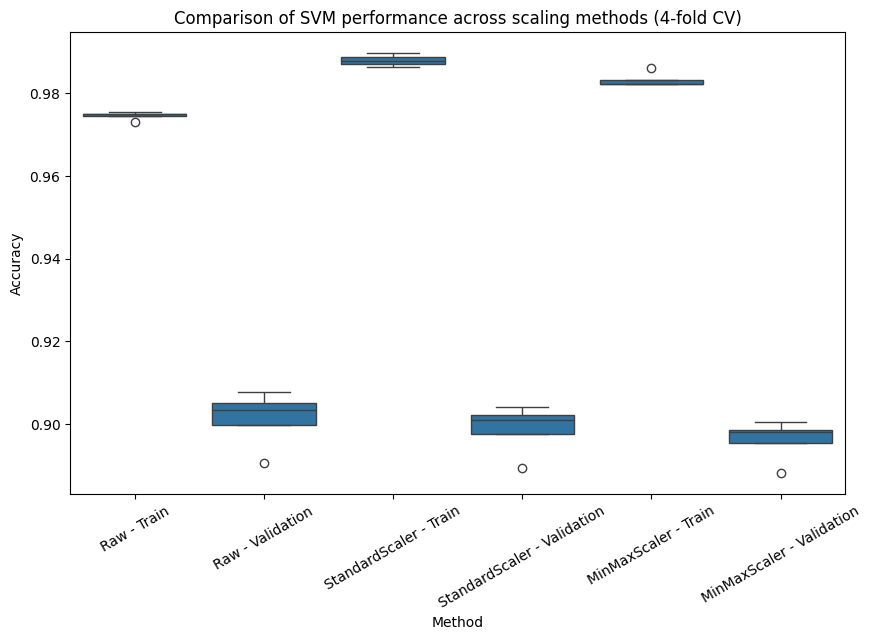

In [31]:
scalers = {
    "Raw": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

svm_results = {}

for name, scaler in scalers.items():
    train_scores = []
    val_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        if scaler:
            X_tr = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)

        svm = SVC(kernel='rbf')
        svm.fit(X_tr, y_tr)

        train_scores.append(svm.score(X_tr, y_tr))
        val_scores.append(svm.score(X_val, y_val))

    svm_results[name] = {
        "Train": train_scores,
        "Validation": val_scores
    }

plot_data = []
for key, scores in svm_results.items():
    for v in scores["Train"]:
        plot_data.append([f"{key} - Train", v])
    for v in scores["Validation"]:
        plot_data.append([f"{key} - Validation", v])

df_plot = pd.DataFrame(plot_data, columns=["Method", "Accuracy"])

plt.figure(figsize=(10,6))
sns.boxplot(x="Method", y="Accuracy", data=df_plot)
plt.xticks(rotation=30)
plt.title("Comparison of SVM performance across scaling methods (4-fold CV)")
plt.show()


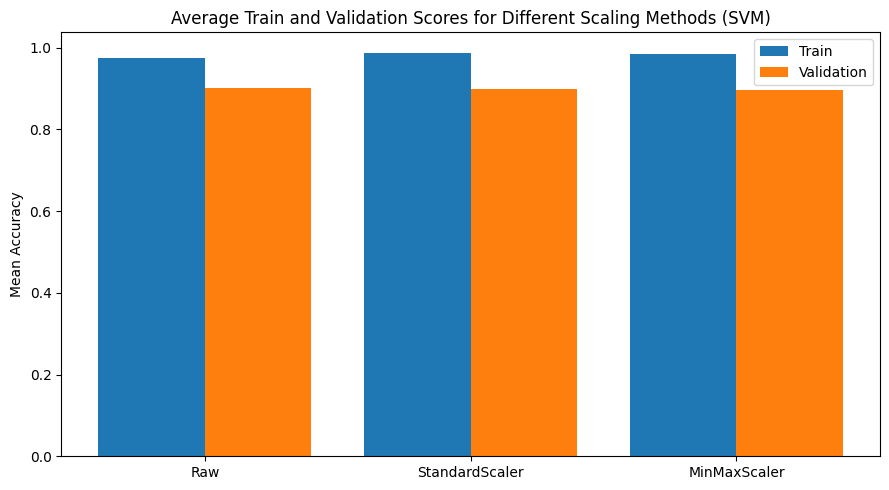

In [32]:
means_train = [np.mean(svm_results[k]["Train"]) for k in svm_results]
means_val = [np.mean(svm_results[k]["Validation"]) for k in svm_results]

labels = list(svm_results.keys())
x = np.arange(len(labels))

plt.figure(figsize=(9,5))
plt.bar(x - 0.2, means_train, 0.4, label="Train")
plt.bar(x + 0.2, means_val, 0.4, label="Validation")
plt.xticks(x, labels)
plt.ylabel("Mean Accuracy")
plt.title("Average Train and Validation Scores for Different Scaling Methods (SVM)")
plt.legend()
plt.tight_layout()
plt.show()


 SVM Cross Validation Results (4-Fold)
CV Accuracy : 0.8563960639606396
CV F1 Score : 0.8504465895289206
CV ROC-AUC  : nan

 SVM Test Results
Test Accuracy : 0.8437884378843789
Test F1 Score : 0.8371680584151138
Test ROC-AUC  : 0.9780086924893162


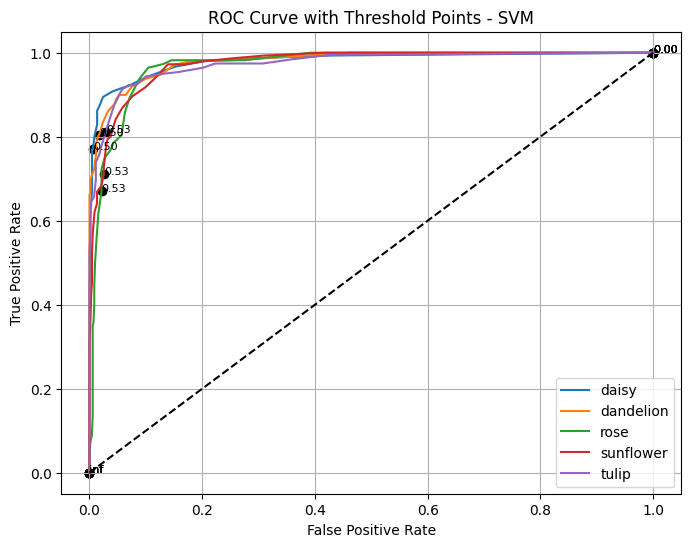

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import make_scorer

# ================= PIPELINE =================
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('fs', VarianceThreshold(0.01)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score, average='macro'),
    'roc_auc': make_scorer(roc_auc_score, multi_class='ovr', needs_proba=True)
}

cv_scores = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print(" SVM Cross Validation Results (4-Fold)")
print("CV Accuracy :", np.mean(cv_scores['test_accuracy']))
print("CV F1 Score :", np.mean(cv_scores['test_f1']))
print("CV ROC-AUC  :", np.mean(cv_scores['test_roc_auc']))


# ================= TRAIN ON FULL TRAINING SET =================
svm_pipeline.fit(X_train, y_train)

y_test_pred = svm_pipeline.predict(X_test)
y_test_prob = svm_pipeline.predict_proba(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
test_auc = roc_auc_score(y_test, y_test_prob, multi_class='ovr')

print("\n SVM Test Results")
print("Test Accuracy :", test_accuracy)
print("Test F1 Score :", test_f1)
print("Test ROC-AUC  :", test_auc)


# ================= ROC CURVE PLOT =================
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob[:, i])

    plt.plot(fpr, tpr, label=f"{class_names[i]}")

    # Mark 3 threshold points for each class
    for j in np.linspace(0, len(thresholds)-1, 3, dtype=int):
        plt.scatter(fpr[j], tpr[j], color='black')
        plt.text(fpr[j], tpr[j],
                 f"{thresholds[j]:.2f}",
                 fontsize=8)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Threshold Points - SVM")
plt.legend()
plt.grid(True)
plt.show()



In [34]:
from sklearn.model_selection import GridSearchCV

svm_pipe_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('fs', VarianceThreshold()),
    ('svm', SVC(probability=True))
])

param_grid = {
    'pca__n_components': [5, 10],
    'svm__C': [1, 10],
    'svm__gamma': [0.01, 0.1]
}

grid = GridSearchCV(
    svm_pipe_gs,
    param_grid,
    cv=4,
    scoring='roc_auc_ovr',
    return_train_score=True
)

grid.fit(X_train, y_train)

grid_results = pd.DataFrame(grid.cv_results_)[
    ['params', 'mean_train_score', 'mean_test_score', 'std_test_score']
]

print("GRIDSEARCH ANALYSIS TABLE:")
display(grid_results)


GRIDSEARCH ANALYSIS TABLE:


,params,mean_train_score,mean_test_score,std_test_score
0,"{'pca__n_components': 5, 'svm__C': 1, 'svm__ga...",0.961537,0.951770,0.003559
1,"{'pca__n_components': 5, 'svm__C': 1, 'svm__ga...",0.988249,0.930879,0.003955
2,"{'pca__n_components': 5, 'svm__C': 10, 'svm__g...",0.970951,0.950614,0.003235
3,"{'pca__n_components': 5, 'svm__C': 10, 'svm__g...",0.999269,0.910569,0.004610
4,"{'pca__n_components': 10, 'svm__C': 1, 'svm__g...",0.990332,0.976942,0.003522
5,"{'pca__n_components': 10, 'svm__C': 1, 'svm__g...",0.999997,0.948010,0.004262
6,"{'pca__n_components': 10, 'svm__C': 10, 'svm__...",0.998522,0.970518,0.003620
7,"{'pca__n_components': 10, 'svm__C': 10, 'svm__...",0.999999,0.946558,0.004790


# **Logistic**

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("fs", VarianceThreshold(threshold=0.01)),
    ("logistic", LogisticRegression(
        penalty="l2",        #  REGULARIZATION
        C=1.0,               # Regularization strength
        max_iter=1000
    ))
])


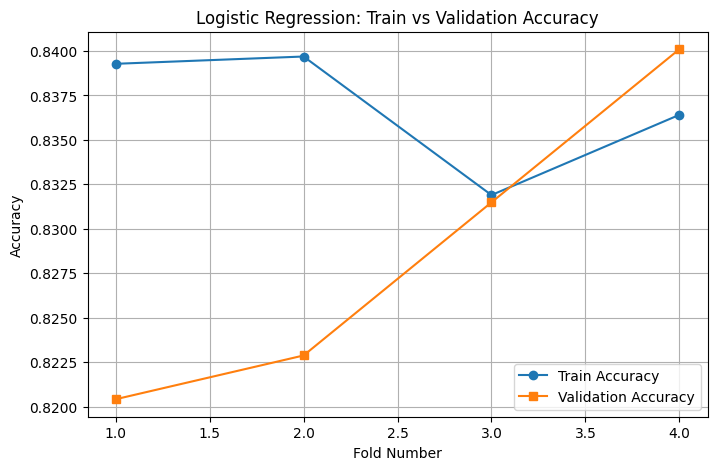

In [36]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

train_acc_scores = []
val_acc_scores = []

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    log_model.fit(X_tr, y_tr)

    train_pred = log_model.predict(X_tr)
    val_pred = log_model.predict(X_val)

    train_acc_scores.append(accuracy_score(y_tr, train_pred))
    val_acc_scores.append(accuracy_score(y_val, val_pred))

# -------- PLOT: TRAIN vs VALIDATION CURVE --------
plt.figure(figsize=(8,5))
plt.plot(range(1,5), train_acc_scores, marker='o', label="Train Accuracy")
plt.plot(range(1,5), val_acc_scores, marker='s', label="Validation Accuracy")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Logistic Regression: Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


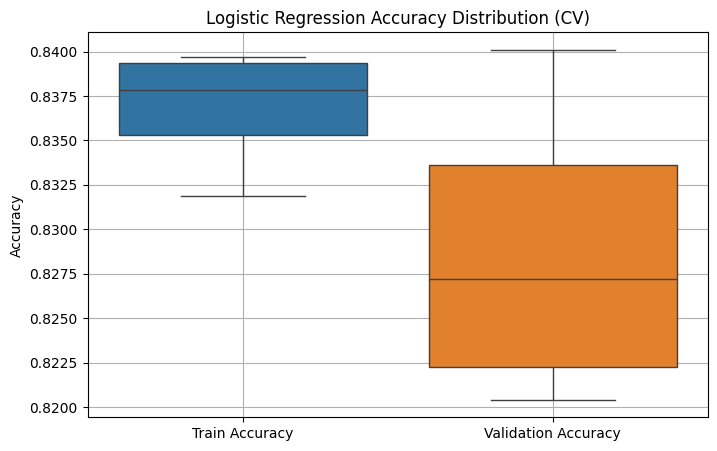

In [37]:
acc_data = {
    "Train Accuracy": train_acc_scores,
    "Validation Accuracy": val_acc_scores
}

acc_df = pd.DataFrame(acc_data)

plt.figure(figsize=(8,5))
sns.boxplot(data=acc_df)
plt.title("Logistic Regression Accuracy Distribution (CV)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


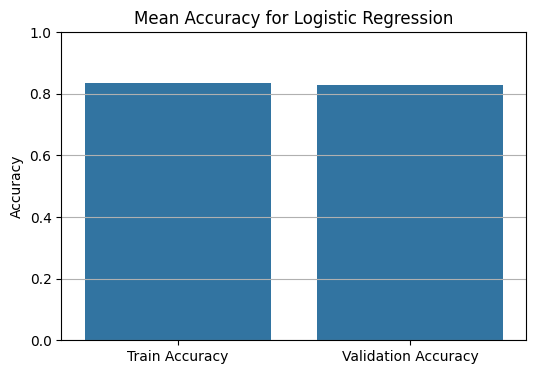

 Mean Train Accuracy: 0.8368
 Mean Validation Accuracy: 0.8287


In [38]:
mean_train_acc = np.mean(train_acc_scores)
mean_val_acc = np.mean(val_acc_scores)

plt.figure(figsize=(6,4))
sns.barplot(
    x=["Train Accuracy", "Validation Accuracy"],
    y=[mean_train_acc, mean_val_acc]
)
plt.title("Mean Accuracy for Logistic Regression")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

print(" Mean Train Accuracy:", round(mean_train_acc,4))
print(" Mean Validation Accuracy:", round(mean_val_acc,4))



 LOGISTIC REGRESSION CV PERFORMANCE
CV Accuracy : 0.8284132841328413
CV F1 Score : 0.8228552032814257
CV ROC-AUC  : 0.9660256445549965


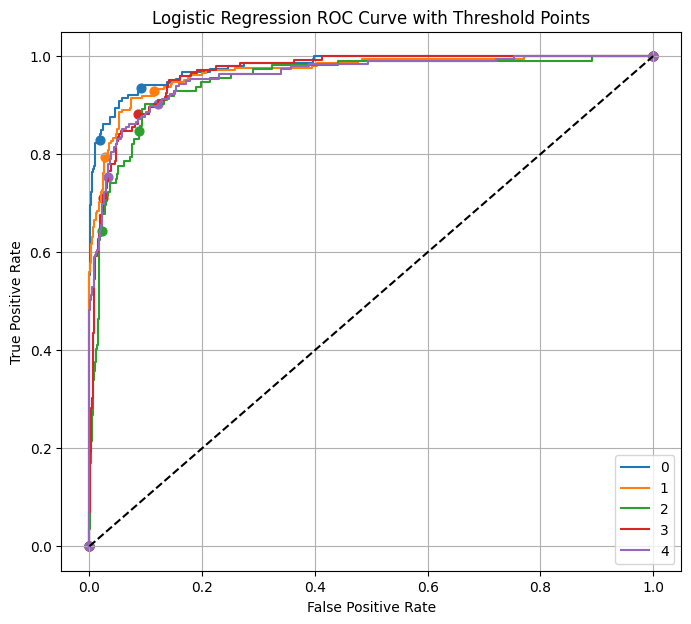

In [39]:

# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score
)

# LOGISTIC REGRESSION PIPELINE

log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("fs", VarianceThreshold(threshold=0.01)),
    ("logistic", LogisticRegression(max_iter=1000, multi_class="ovr"))
])


# CROSS VALIDATION

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

cv_scores = cross_validate(
    log_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1_macro",
        "roc_auc": "roc_auc_ovr"
    }
)

print("\n LOGISTIC REGRESSION CV PERFORMANCE")
print("CV Accuracy :", np.mean(cv_scores["test_accuracy"]))
print("CV F1 Score :", np.mean(cv_scores["test_f1"]))
print("CV ROC-AUC  :", np.mean(cv_scores["test_roc_auc"]))


# TRAIN FINAL MODEL ON FULL TRAIN SET

log_pipeline.fit(X_train, y_train)


# PREDICT PROBABILITIES ON TEST SET

y_prob_log = log_pipeline.predict_proba(X_test)


# BINARIZE TEST LABELS FOR ROC

class_names = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=class_names)


# ROC CURVE FOR EACH CLASS WITH THRESHOLD MARKERS

plt.figure(figsize=(8, 7))

for i, class_name in enumerate(class_names):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob_log[:, i])
    plt.plot(fpr, tpr, label=f"{class_name}")

    # Mark 4 threshold points on each curve
    idx = np.linspace(0, len(thresholds) - 1, 4, dtype=int)
    plt.scatter(fpr[idx], tpr[idx], s=40)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve with Threshold Points")
plt.legend()
plt.grid(True)
plt.show()


#  **classifier** **comparison** plots

In [40]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_validate
from time import time

models = {
    "KNN": KNeighborsClassifier(n_neighbors=30, metric="minkowski"),
    "SVM": SVC(probability=True, kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(
        penalty="l2",
        max_iter=1000,
        multi_class="ovr"
    )

}

performance = {}

for name, model in models.items():

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=10)),
        ('fs', VarianceThreshold(0.01)),
        ('model', model)
    ])

    start_train = time()
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=4,
        scoring={
            'accuracy': 'accuracy',
            'f1': make_scorer(f1_score, average='macro'),
            'roc_auc': make_scorer(roc_auc_score, multi_class='ovr')
        },
        return_train_score=True
    )
    end_train = time()

    pipeline.fit(X_train, y_train)

    start_test = time()
    y_test_pred = pipeline.predict(X_test)
    y_test_prob = pipeline.predict_proba(X_test)
    end_test = time()

    performance[name] = {
        "CV_Accuracy": np.mean(cv_scores['test_accuracy']),
        "CV_F1": np.mean(cv_scores['test_f1']),
        "CV_ROC_AUC": np.mean(cv_scores['test_roc_auc']),
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Test_F1": f1_score(y_test, y_test_pred, average='macro'),
        "Test_ROC_AUC": roc_auc_score(y_test, y_test_prob, multi_class='ovr'),
        "Train_Time": end_train - start_train,
        "Test_Time": end_test - start_test
    }


In [41]:
comparison_df = pd.DataFrame(performance).T
display(comparison_df)


,CV_Accuracy,CV_F1,CV_ROC_AUC,Test_Accuracy,Test_F1,Test_ROC_AUC,Train_Time,Test_Time
KNN,0.841636,0.834434,NaN,0.847478,0.840245,0.975932,2.250827,0.137787
SVM,0.853936,0.848173,NaN,0.843788,0.837261,0.978065,6.356685,0.254770
Random Forest,0.830258,0.821745,NaN,0.845018,0.839114,0.973373,17.814625,0.142538
Logistic Regression,0.825953,0.819752,NaN,0.825338,0.818716,0.964706,2.703691,0.022676


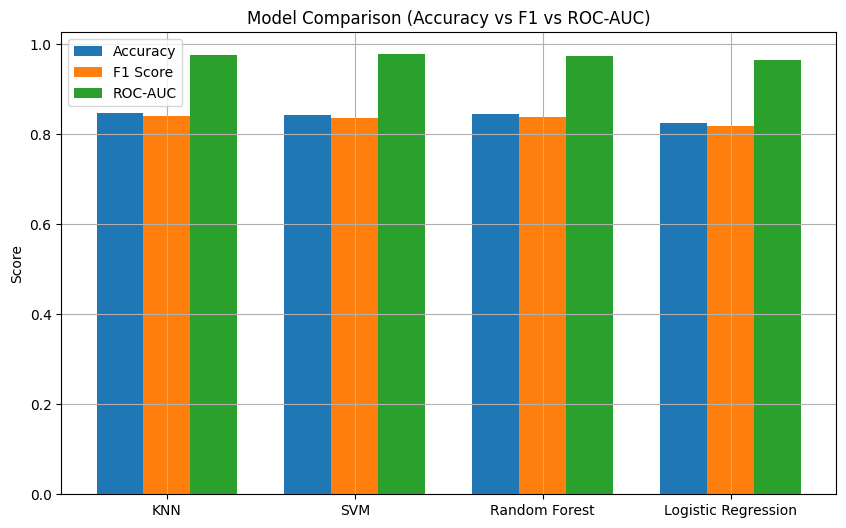

In [42]:
models_list = list(performance.keys())

acc = [performance[m]["Test_Accuracy"] for m in models_list]
f1 = [performance[m]["Test_F1"] for m in models_list]
auc = [performance[m]["Test_ROC_AUC"] for m in models_list]

x = np.arange(len(models_list))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, acc, width, label='Accuracy')
plt.bar(x, f1, width, label='F1 Score')
plt.bar(x + width, auc, width, label='ROC-AUC')

plt.xticks(x, models_list)
plt.ylabel("Score")
plt.title("Model Comparison (Accuracy vs F1 vs ROC-AUC)")
plt.legend()
plt.grid(True)
plt.show()


In [58]:
train_acc = [performance[m]["CV_Accuracy"] for m in models_list]
test_acc = [performance[m]["Test_Accuracy"] for m in models_list]

plt.figure(figsize=(10,6))
plt.plot(models_list, train_acc, marker='o', label="CV Accuracy")
plt.plot(models_list, test_acc, marker='s', label="Test Accuracy")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy of Classifiers")
plt.legend()
plt.grid(True)
plt.show()


KeyError: 'RandomForest'

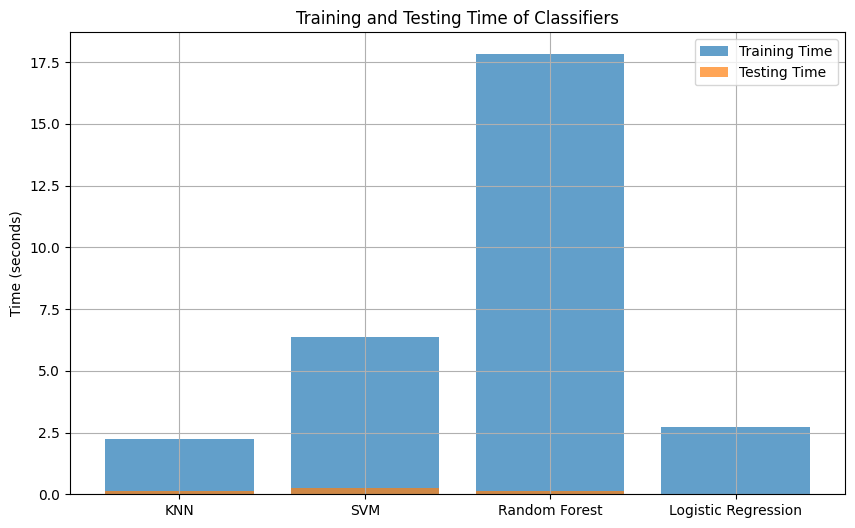

In [44]:
train_time = [performance[m]["Train_Time"] for m in models_list]
test_time = [performance[m]["Test_Time"] for m in models_list]

plt.figure(figsize=(10,6))
plt.bar(models_list, train_time, label="Training Time", alpha=0.7)
plt.bar(models_list, test_time, label="Testing Time", alpha=0.7)
plt.ylabel("Time (seconds)")
plt.title("Training and Testing Time of Classifiers")
plt.legend()
plt.grid(True)
plt.show()






# **Esemble methods**

In [45]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt
import time

ada_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ada', AdaBoostClassifier(n_estimators=150, random_state=42))
])

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_macro',
    'roc_auc': 'roc_auc_ovr'
}


start = time.time()
cv_scores_ada = cross_validate(ada_pipe, X_train, y_train, cv=4, scoring=scoring)
cv_time_ada = time.time() - start

print(" AdaBoost 4-Fold CV Results")
print("CV Accuracy :", np.mean(cv_scores_ada['test_accuracy']))
print("CV F1-score :", np.mean(cv_scores_ada['test_f1']))
print("CV ROC-AUC  :", np.mean(cv_scores_ada['test_roc_auc']))


ada_pipe.fit(X_train, y_train)
y_pred = ada_pipe.predict(X_test)
y_prob = ada_pipe.predict_proba(X_test)

print("\n AdaBoost Test Set Results")
print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("Test F1-score :", f1_score(y_test, y_pred, average='macro'))
print("Test ROC-AUC  :", roc_auc_score(y_test, y_prob, multi_class='ovr'))


 AdaBoost 4-Fold CV Results
CV Accuracy : 0.7813653136531366
CV F1-score : 0.7727210387156106
CV ROC-AUC  : 0.9314979510333699

 AdaBoost Test Set Results
Test Accuracy : 0.7613776137761378
Test F1-score : 0.7519856702342328
Test ROC-AUC  : 0.9311300153620075


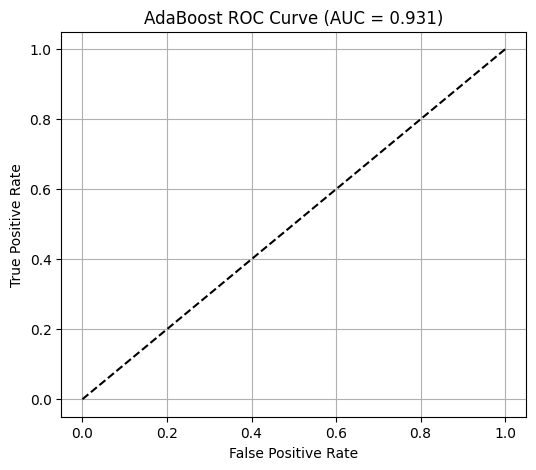

In [46]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
roc_auc = roc_auc_score(y_test_bin, y_prob, average='macro')

plt.figure(figsize=(6,5))
plt.plot([0,1], [0,1], 'k--')
plt.title(f"AdaBoost ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()


In [47]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=20)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('svm', SVC(probability=True))
]

meta_model = LogisticRegression()

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

stack_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('stack', stack_model)
])

# ===== STACKING CV =====
cv_scores_stack = cross_validate(stack_pipe, X_train, y_train, cv=4, scoring=scoring)

print("\n Stacking 4-Fold CV Results")
print("CV Accuracy :", np.mean(cv_scores_stack['test_accuracy']))
print("CV F1-score :", np.mean(cv_scores_stack['test_f1']))
print("CV ROC-AUC  :", np.mean(cv_scores_stack['test_roc_auc']))

# ===== STACKING TEST =====
stack_pipe.fit(X_train, y_train)
y_pred_stack = stack_pipe.predict(X_test)
y_prob_stack = stack_pipe.predict_proba(X_test)

print("\n Stacking Test Results")
print("Test Accuracy :", accuracy_score(y_test, y_pred_stack))
print("Test F1-score :", f1_score(y_test, y_pred_stack, average='macro'))
print("Test ROC-AUC  :", roc_auc_score(y_test, y_prob_stack, multi_class='ovr'))



 Stacking 4-Fold CV Results
CV Accuracy : 0.9022140221402214
CV F1-score : 0.8967314351793626
CV ROC-AUC  : 0.989752786915191

 Stacking Test Results
Test Accuracy : 0.9089790897908979
Test F1-score : 0.9053967566209911
Test ROC-AUC  : 0.9879547448821862


# **comparison of all**

In [48]:


# ===================== 4. STANDARD PIPELINE FOR ALL MODELS =====================
def build_pipeline(model):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=10)),
        ('fs', VarianceThreshold(threshold=0.01)),
        ('model', model)
    ])

# ===================== 5. MODELS =====================
models = {
    'KNN': KNeighborsClassifier(n_neighbors=30),
    'SVM': SVC(probability=True),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42),
    "Logistic Regression": LogisticRegression(
        penalty="l2",
        max_iter=1000,
        multi_class="ovr"
    ),

    'AdaBoost': AdaBoostClassifier(n_estimators=200),
}

# ===================== 6. STACKING =====================
stack_model = StackingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(20)),
        ('rf', RandomForestClassifier(200)),
        ('svm', SVC(probability=True))
    ],
    final_estimator=LogisticRegression()
)
models['Stacking'] = stack_model

# ===================== 7. PERFORMANCE STORAGE =====================
results = {}

# ===================== 8. MODEL EVALUATION LOOP =====================
for name, model in models.items():

    pipe = build_pipeline(model)

    start_train = time.time()
    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'f1': 'f1_macro',
            'roc_auc': 'roc_auc_ovr'
        }
    )
    train_time = time.time() - start_train

    pipe.fit(X_train, y_train)

    start_test = time.time()
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)
    test_time = time.time() - start_test

    results[name] = {
        'CV_Accuracy': np.mean(cv_scores['test_accuracy']),
        'CV_F1': np.mean(cv_scores['test_f1']),
        'CV_ROC_AUC': np.mean(cv_scores['test_roc_auc']),
        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Test_F1': f1_score(y_test, y_pred, average='macro'),
        'Test_ROC_AUC': roc_auc_score(y_test, y_prob, multi_class='ovr'),
        'Train_Time': train_time,
        'Test_Time': test_time
    }




In [49]:
# ===================== 9. RESULTS TABLE =====================
results_df = pd.DataFrame(results).T
print('\n FINAL PERFORMANCE TABLE')
print(results_df)




 FINAL PERFORMANCE TABLE
                     CV_Accuracy     CV_F1  CV_ROC_AUC  Test_Accuracy  \
KNN                     0.844403  0.838613    0.973371       0.846248   
SVM                     0.855474  0.849471    0.978520       0.843788   
RandomForest            0.830258  0.823046    0.972488       0.830258   
Logistic Regression     0.828721  0.823064    0.966028       0.825338   
AdaBoost                0.782288  0.771119    0.933832       0.788438   
Stacking                0.854551  0.847714    0.978113       0.848708   

                      Test_F1  Test_ROC_AUC  Train_Time  Test_Time  
KNN                  0.838834      0.975876    1.935737   0.170164  
SVM                  0.837204      0.978033    4.602606   0.253206  
RandomForest         0.823250      0.972333   14.917460   0.161972  
Logistic Regression  0.818589      0.964818    1.698787   0.009493  
AdaBoost             0.777792      0.933335    8.625092   0.152202  
Stacking             0.841647      0.977165   57

In [50]:
from sklearn.metrics import classification_report

print("\n================== CLASSIFICATION REPORTS (ALL MODELS) ==================\n")

# Convert class names to strings to avoid numpy.int64 errors
target_names = [str(c) for c in class_names]

for name, model in models.items():
    print(f"\n----- {name} -----\n")

    # rebuild pipeline for this model
    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train)

    # predictions
    y_pred = pipe.predict(X_test)

    # print report
    print(classification_report(y_test, y_pred, target_names=target_names))



================== CLASSIFICATION REPORTS (ALL MODELS) ==================


----- KNN -----

              precision    recall  f1-score   support

           0       0.92      0.87      0.89       152
           1       0.91      0.87      0.89       209
           2       0.74      0.79      0.76       112
           3       0.79      0.83      0.81       145
           4       0.84      0.86      0.85       195

    accuracy                           0.85       813
   macro avg       0.84      0.84      0.84       813
weighted avg       0.85      0.85      0.85       813


----- SVM -----

              precision    recall  f1-score   support

           0       0.89      0.88      0.89       152
           1       0.90      0.88      0.89       209
           2       0.77      0.78      0.77       112
           3       0.82      0.81      0.81       145
           4       0.82      0.85      0.84       195

    accuracy                           0.85       813
   macro avg       


 BOXPLOT COMPARISON: CLASSIFIER PERFORMANCE (4-FOLD CV)


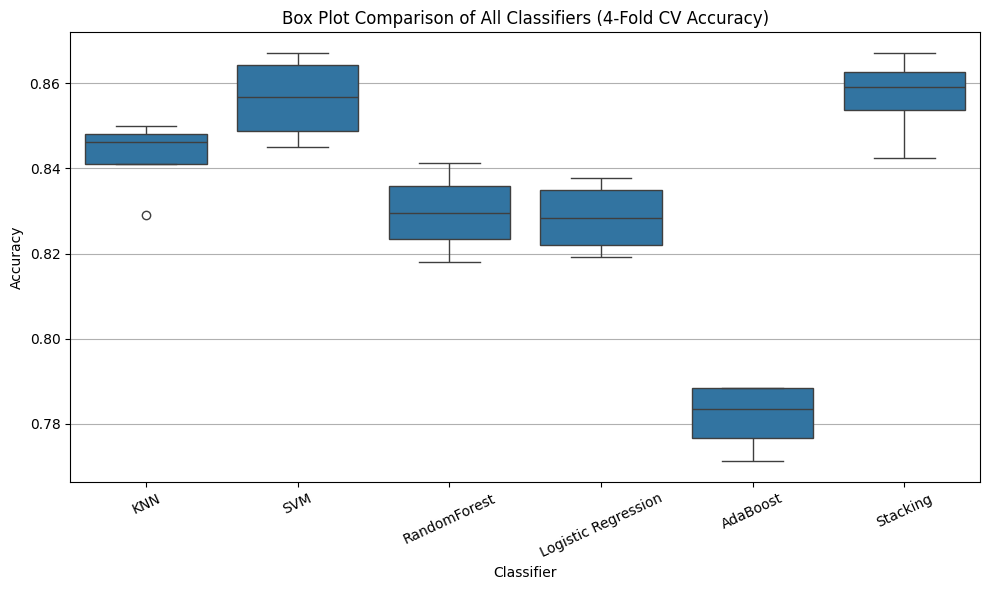

In [51]:
# ================== BOXPLOT COMPARISON OF ALL CLASSIFIERS ==================

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

print("\n BOXPLOT COMPARISON: CLASSIFIER PERFORMANCE (4-FOLD CV)")

boxplot_data = []

for name, model in models.items():

    pipe = build_pipeline(model)

    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy',
        return_train_score=False
    )

    # Store each fold's accuracy
    for score in cv_scores['test_score']:
        boxplot_data.append([name, score])


box_df = pd.DataFrame(boxplot_data, columns=["Classifier", "Accuracy"])


# --------- BOXPLOT ---------
plt.figure(figsize=(10,6))
sns.boxplot(x="Classifier", y="Accuracy", data=box_df)

plt.title("Box Plot Comparison of All Classifiers (4-Fold CV Accuracy)")
plt.ylabel("Accuracy")
plt.xlabel("Classifier")
plt.xticks(rotation=25)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


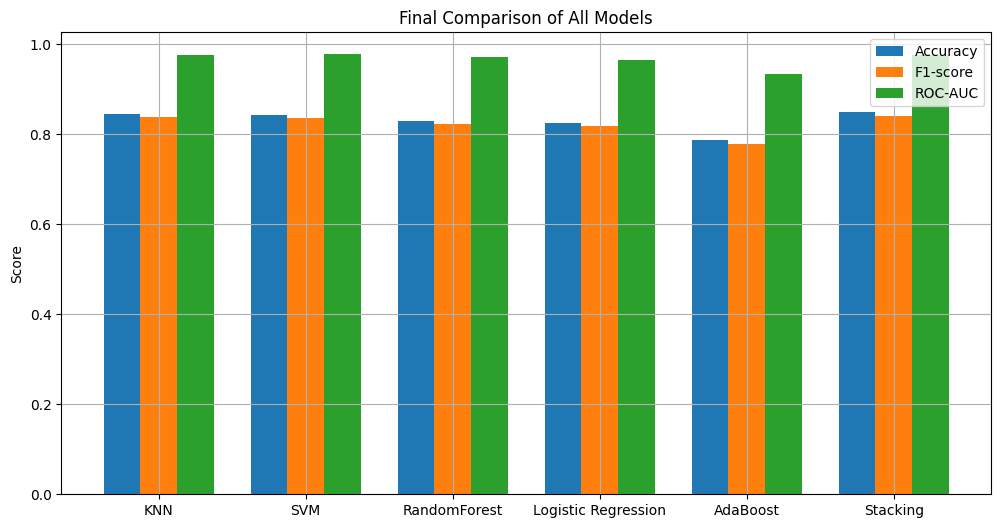

In [52]:
# ===================== 10. FINAL COMPARISON PLOTS =====================
models_list = results_df.index

acc = results_df['Test_Accuracy']
f1 = results_df['Test_F1']
auc = results_df['Test_ROC_AUC']

x = np.arange(len(models_list))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x-width, acc, width, label='Accuracy')
plt.bar(x, f1, width, label='F1-score')
plt.bar(x+width, auc, width, label='ROC-AUC')
plt.xticks(x, models_list)
plt.ylabel('Score')
plt.title('Final Comparison of All Models')
plt.legend()
plt.grid()
plt.show()



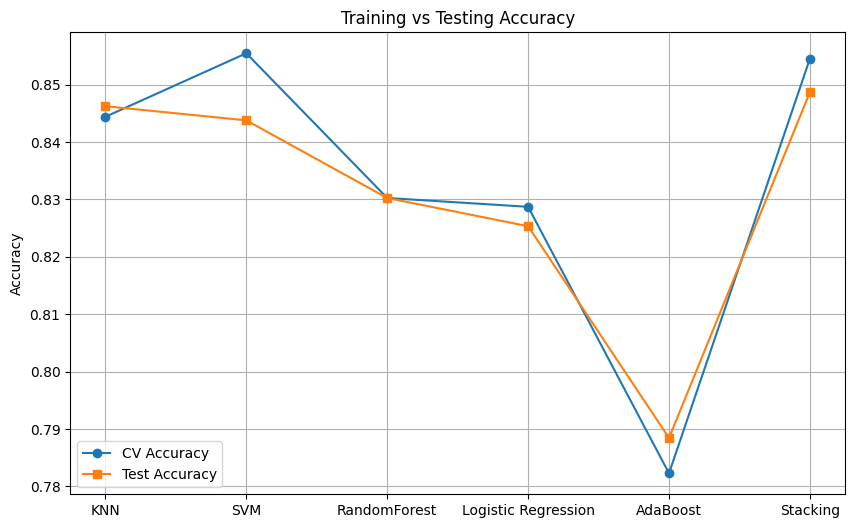

In [53]:
# ===================== 11. TRAIN vs TEST ACCURACY =====================
train_acc = results_df['CV_Accuracy']
test_acc = results_df['Test_Accuracy']

plt.figure(figsize=(10,6))
plt.plot(models_list, train_acc, marker='o', label='CV Accuracy')
plt.plot(models_list, test_acc, marker='s', label='Test Accuracy')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')
plt.legend()
plt.grid()
plt.show()



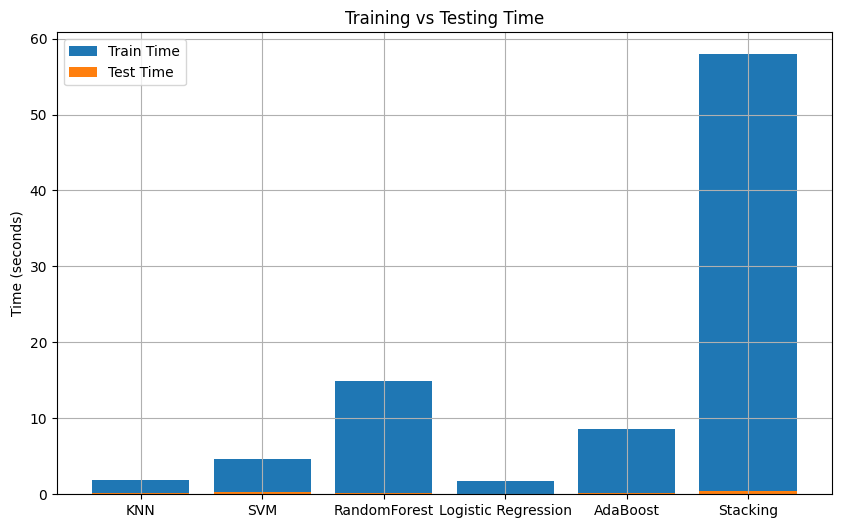

In [54]:
# ===================== 12. TRAIN vs TEST TIME =====================
train_times = results_df['Train_Time']
test_times = results_df['Test_Time']

plt.figure(figsize=(10,6))
plt.bar(models_list, train_times, label='Train Time')
plt.bar(models_list, test_times, label='Test Time')
plt.ylabel('Time (seconds)')
plt.title('Training vs Testing Time')
plt.legend()
plt.grid()
plt.show()


✅ CONFUSION MATRICES WITH HEATMAP FOR ALL CLASSIFIERS

--- KNN Confusion Matrix ---


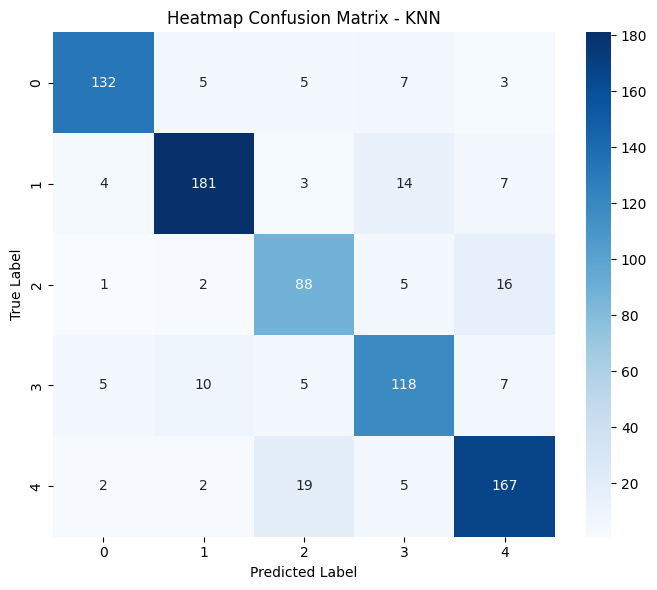


--- SVM Confusion Matrix ---


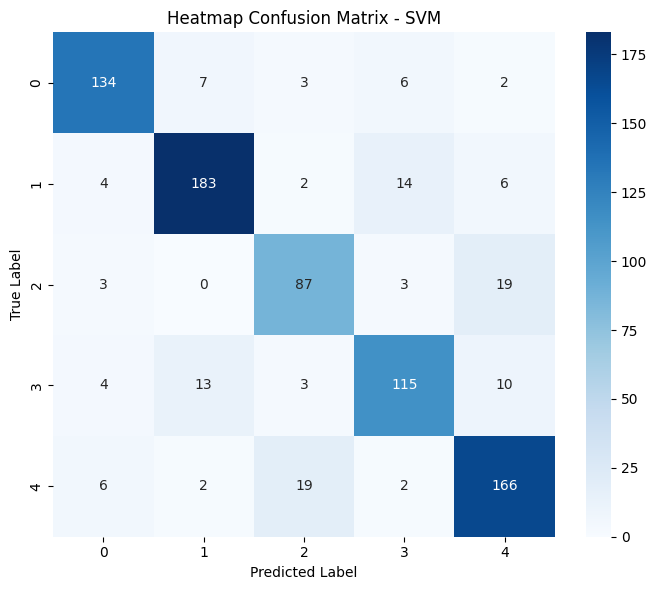


--- RandomForest Confusion Matrix ---


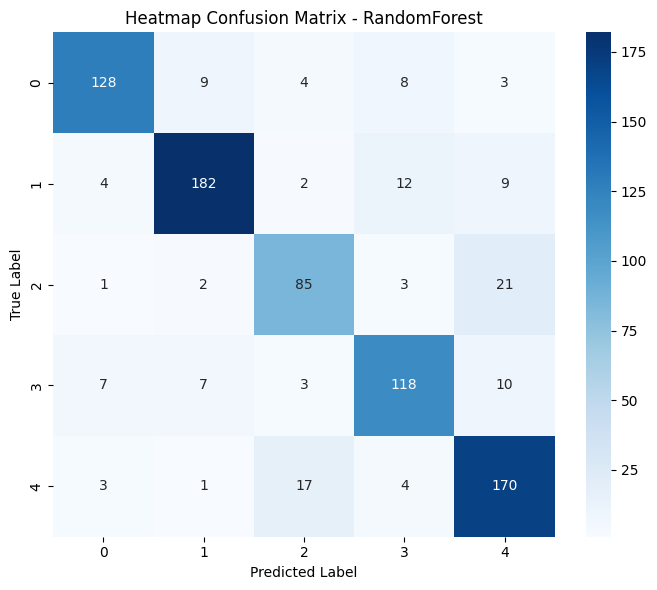


--- Logistic Regression Confusion Matrix ---


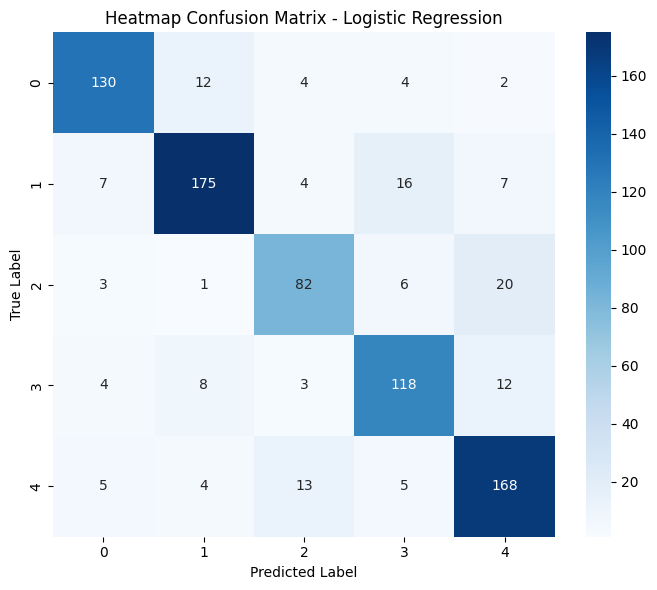


--- AdaBoost Confusion Matrix ---


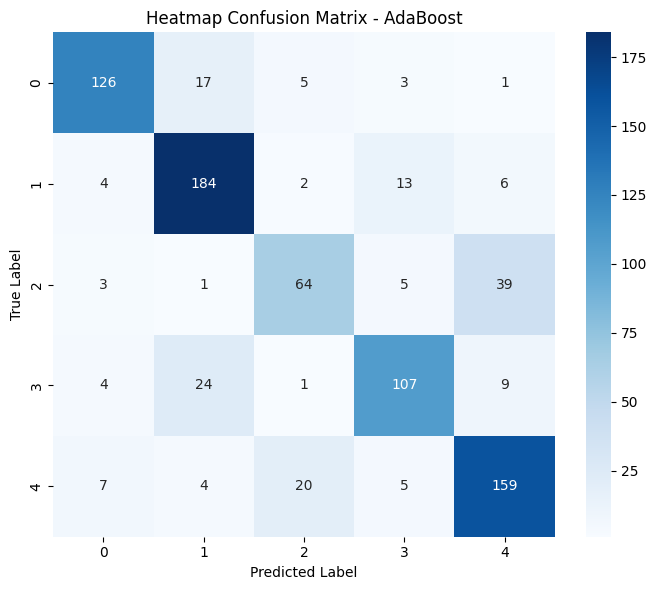


--- Stacking Confusion Matrix ---


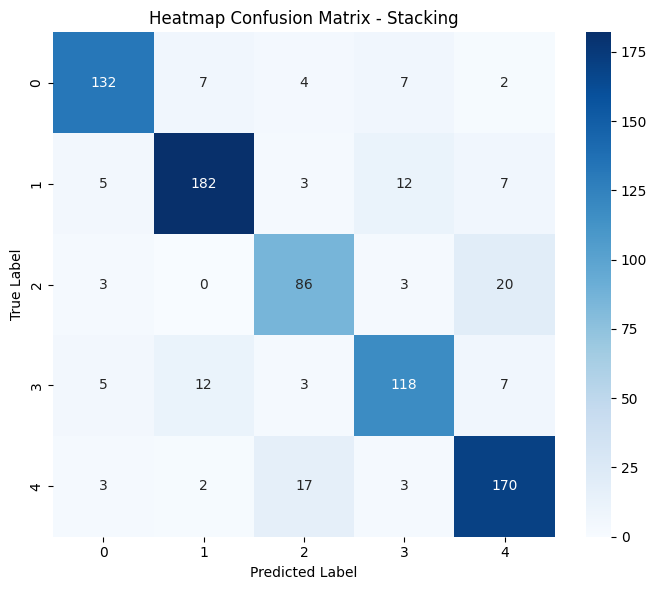

In [55]:
# ===================== 13. CONFUSION MATRIX + HEATMAP (ALL MODELS) =====================
print("\n✅ CONFUSION MATRICES WITH HEATMAP FOR ALL CLASSIFIERS")

from sklearn.metrics import confusion_matrix

for name, model in models.items():

    print(f"\n--- {name} Confusion Matrix ---")

    # Rebuild pipeline to avoid interference
    pipe = build_pipeline(model)

    # Train model
    pipe.fit(X_train, y_train)

    # Predict on test set
    y_pred = pipe.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot heatmap only (no text confusion matrix)
    plt.figure(figsize=(7,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Heatmap Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()


 CORRELATION OF CLASSIFIER PREDICTIONS (FUSION JUSTIFICATION)
                          KNN       SVM  Random Forest  Logistic Regression
KNN                  1.000000  0.834596       0.884587             0.832949
SVM                  0.834596  1.000000       0.873142             0.873008
Random Forest        0.884587  0.873142       1.000000             0.852080
Logistic Regression  0.832949  0.873008       0.852080             1.000000


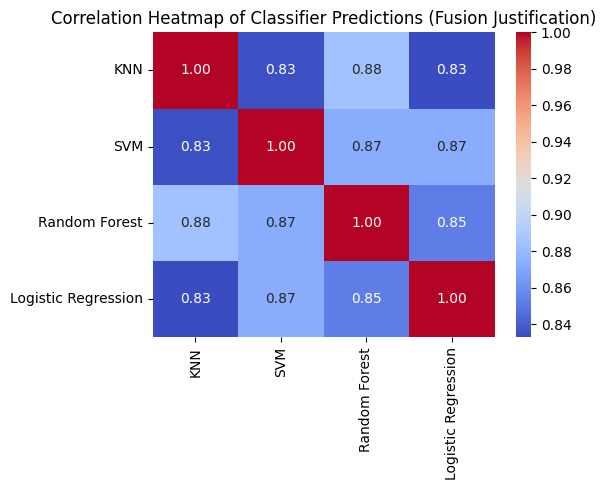

FUSION CORRELATION HEATMAP GENERATED SUCCESSFULLY


In [56]:
print(" CORRELATION OF CLASSIFIER PREDICTIONS (FUSION JUSTIFICATION)")

# Re-fit KNN
knn_corr = KNeighborsClassifier(n_neighbors=5)
knn_corr.fit(X_train, y_train)
knn_pred_corr = knn_corr.predict(X_test)

# Re-fit SVM
svm_corr = SVC(kernel='linear')
svm_corr.fit(X_train, y_train)
svm_pred_corr = svm_corr.predict(X_test)

# Re-fit Random Forest
rf_corr = RandomForestClassifier(n_estimators=300, random_state=42)
rf_corr.fit(X_train, y_train)
rf_pred_corr = rf_corr.predict(X_test)

#  Re-fit Logistic Regression (FIXED)
log_corr = LogisticRegression(max_iter=1000, multi_class="ovr")
log_corr.fit(X_train, y_train)
log_pred_corr = log_corr.predict(X_test)

# Collect predictions
predictions_matrix = {
    "KNN": knn_pred_corr,
    "SVM": svm_pred_corr,
    "Random Forest": rf_pred_corr,
    "Logistic Regression": log_pred_corr
}

pred_df = pd.DataFrame(predictions_matrix)

# Compute correlation
corr_matrix = pred_df.corr()
print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Classifier Predictions (Fusion Justification)")
plt.tight_layout()
plt.show()

print("FUSION CORRELATION HEATMAP GENERATED SUCCESSFULLY")


In [59]:
print("Best Final Model:", results_df['Test_ROC_AUC'].idxmax())


Best Final Model: SVM


# **Testing:**

In [68]:

# PART 3 – FINAL TEST PREDICTIONS using best model


import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC

# 1. Load training data
X_train = pd.read_csv("flower_train_features.csv").values
y_train = pd.read_csv("flower_train_labels.csv")["label"].values

# Label mapping (0–4 -> flower name)
label_map = pd.read_csv("flower_label_mapping.csv")   # columns: label_id, class_name
id_to_name = dict(zip(label_map["label_id"], label_map["class_name"]))

print("Training shape:", X_train.shape, y_train.shape)

# 2. Load test features
X_test_final = pd.read_csv("flower_test_features.csv").values
print("Test feature shape:", X_test_final.shape)

# 3. Build BEST SVM pipeline
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("fs", VarianceThreshold(threshold=0.01)),
    ("svm", SVC(C=10, gamma=0.1, kernel="rbf", probability=True, random_state=42))
])

print("\nTraining BEST SVM model on full training data...")
best_model.fit(X_train, y_train)
print("Best SVM model trained!")

# 4. Predict numeric labels for test data
y_test_pred = best_model.predict(X_test_final)           # numeric labels 0–4
y_test_names = [id_to_name[int(i)] for i in y_test_pred] # class names

print("\nFirst 10 numeric labels:", y_test_pred[:10])
print("First 10 class names    :", y_test_names[:10])
print("Total predictions:", len(y_test_pred))

# 5. Create predictions DataFrame
results_df = pd.DataFrame({
    "sample_id": np.arange(len(y_test_pred)),
    "predicted_label": y_test_names,       # string labels (like dandelion, tulip, ...)
    "predicted_label_id": y_test_pred      # numeric labels (0–4)
})

# 6. Save to CSV (like in the dummy example)
results_df.to_csv("flower_test_predictions.csv", index=False)

print("\n Saved predictions to flower_test_predictions.csv")
print(results_df.head())


Training shape: (4065, 512) (4065,)
Test feature shape: (35, 512)

Training BEST SVM model on full training data...
Best SVM model trained!

First 10 numeric labels: [4 0 1 4 4 1 3 4 4 1]
First 10 class names    : ['tulip', 'daisy', 'dandelion', 'tulip', 'tulip', 'dandelion', 'sunflower', 'tulip', 'tulip', 'dandelion']
Total predictions: 35

 Saved predictions to flower_test_predictions.csv
   sample_id predicted_label  predicted_label_id
0          0           tulip                   4
1          1           daisy                   0
2          2       dandelion                   1
3          3           tulip                   4
4          4           tulip                   4
